# Figure 3G — transcription factor activity across knockouts

Scores every knockout against each transcription factor, keeps the
significant effects, and orders knockouts by guide module to show which
modules act through which factors. Also checks how much the factors' target
sets overlap, since highly similar factors cannot be told apart.

## Setup

In [1]:
library(pheatmap)
library(data.table)
library(repr)

# NOTE: Main.R is deliberately not sourced. It loads ICtest, whose Ops method
# conflicts with the S7 objects in ggplot2 4.x; only what this notebook uses
# is loaded here.

`%ni%` <- Negate(`%in%`)

save_pheatmap_pdf <- function(x, filename, width = 7, height = 7) {
    stopifnot(!missing(x), !missing(filename))
    pdf(filename, width = width, height = height)
    grid::grid.newpage(); grid::grid.draw(x$gtable); dev.off()
}

dir.create("figures", showWarnings = FALSE)
dir.create("outputs", showWarnings = FALSE)

In [2]:
E3LIGASE <- "/home/eraslab1/Projects/E3Ligase/analysisSingle"

E3_METADATA   <- file.path(E3LIGASE, "ManuscriptFigures/TextFiles/220610_regulators_metadata_E3_Complex.csv")
GUIDE_MODULES <- file.path(E3LIGASE, "TextFiles/ME_GuideModules_leiden_6_Modules.csv")
TF_PVALS      <- file.path(E3LIGASE, "TF_score_Pvals.csv")
TF_COEFS      <- file.path(E3LIGASE, "TF_score_Coefs.csv")
TF_TARGETS    <- file.path(E3LIGASE, "TextFiles/TF_targets.csv")
SCORED_TFS    <- file.path(E3LIGASE, "TextFiles/ScoredTFs.csv")

FDR_THRESHOLD    <- 0.1    # scores less significant than this are set to zero
EFFECT_LIMIT     <- 0.1    # colour scale, applied to the scores themselves
MIN_KOS_PER_TF   <- 10     # a factor must be affected by this many knockouts
MIN_TFS_PER_KO   <- 10     # a knockout must affect this many factors
MIN_KOS_PER_TF_E3 <- 5     # looser, for the E3-only panel
JACCARD_CAP      <- 0.5    # colour cap on the target-overlap heatmap

# covariates carried in the score tables that are not knockouts
NOT_A_KNOCKOUT <- c("n_genes", "mt_frac", as.character(0:9))

annoCols <- list(
    GeneGroup = c(G0 = "#1B9E77", G1 = "#D95F02", G2 = "#7570B3", G3 = "#E7298A",
                  G4 = "#66A61E", G5 = "#E6AB02", G6 = "#A6761D", G7 = "#666666"),
    GuideGroup = c(M1 = "#aa40fc", M2 = "#1f77b4", M3 = "#ff7f0e",
                   M4 = "#8c564b", M5 = "#d62728", M6 = "#279e68")
)

# every heatmap here shares this look
scoreHeatmap <- function(mat, annotation = NULL, clusterRows = TRUE,
                         method = "ward.D2", treeheightCol = 0) {
    pheatmap(mat,
             colorRampPalette(c("blue", "white", "orange"))(100),
             clustering_method = method,
             annotation_row = annotation,
             annotation_colors = annoCols,
             cluster_rows = clusterRows,
             treeheight_col = treeheightCol,
             clustering_distance_rows = "euclidean",
             clustering_distance_cols = "euclidean")
}

## E3 ligases, ICA factors and guide modules

In [3]:
realE3s <- as.data.frame(read.csv(E3_METADATA), stringsAsFactors = FALSE)
e3s <- unique(realE3s$Symbol_guides)
e3s <- e3s[e3s != '']

guideModules <- read.csv(GUIDE_MODULES, row.names = 1)
guideModules$GuideGroup <- guideModules$NewGuideGroup   # modules are named M1..M6
guideModules$NewGuideGroup <- NULL
guideModules$GuideColor <- NULL

annoRow <- copy(guideModules)          # keeps GuideName, for selecting rows
guideModules$GuideName <- NULL         # annotation frames want the group alone

cat("E3 ligases:", length(e3s), " knockouts:", nrow(guideModules), "\n")

E3 ligases: 165  knockouts: 329 


## Transcription factor scores

Scores are FDR corrected per factor, and anything not significant is set to
zero so only supported effects contribute.

In [4]:
pVals <- read.csv(TF_PVALS, row.names = 1)
coefs <- read.csv(TF_COEFS, row.names = 1)
pVals <- pVals[rownames(pVals) %ni% NOT_A_KNOCKOUT, ]
coefs <- coefs[rownames(coefs) %ni% NOT_A_KNOCKOUT, ]

pValsAllAdj <- as.data.frame(sapply(pVals, function(x) p.adjust(x, method = "fdr", n = length(x))))
coefs[pValsAllAdj > FDR_THRESHOLD] <- 0

rownames(coefs) <- sapply(rownames(coefs), function(x) strsplit(x, "_")[[1]][2])
coefs <- coefs[rownames(guideModules), ]
write.csv(coefs, "outputs/TF_score_Coefs_Katie.csv")

# clamp for display; downstream panels use these clamped values
coefs[coefs >  EFFECT_LIMIT] <-  EFFECT_LIMIT
coefs[coefs < -EFFECT_LIMIT] <- -EFFECT_LIMIT
dim(coefs)

[1] 329 125

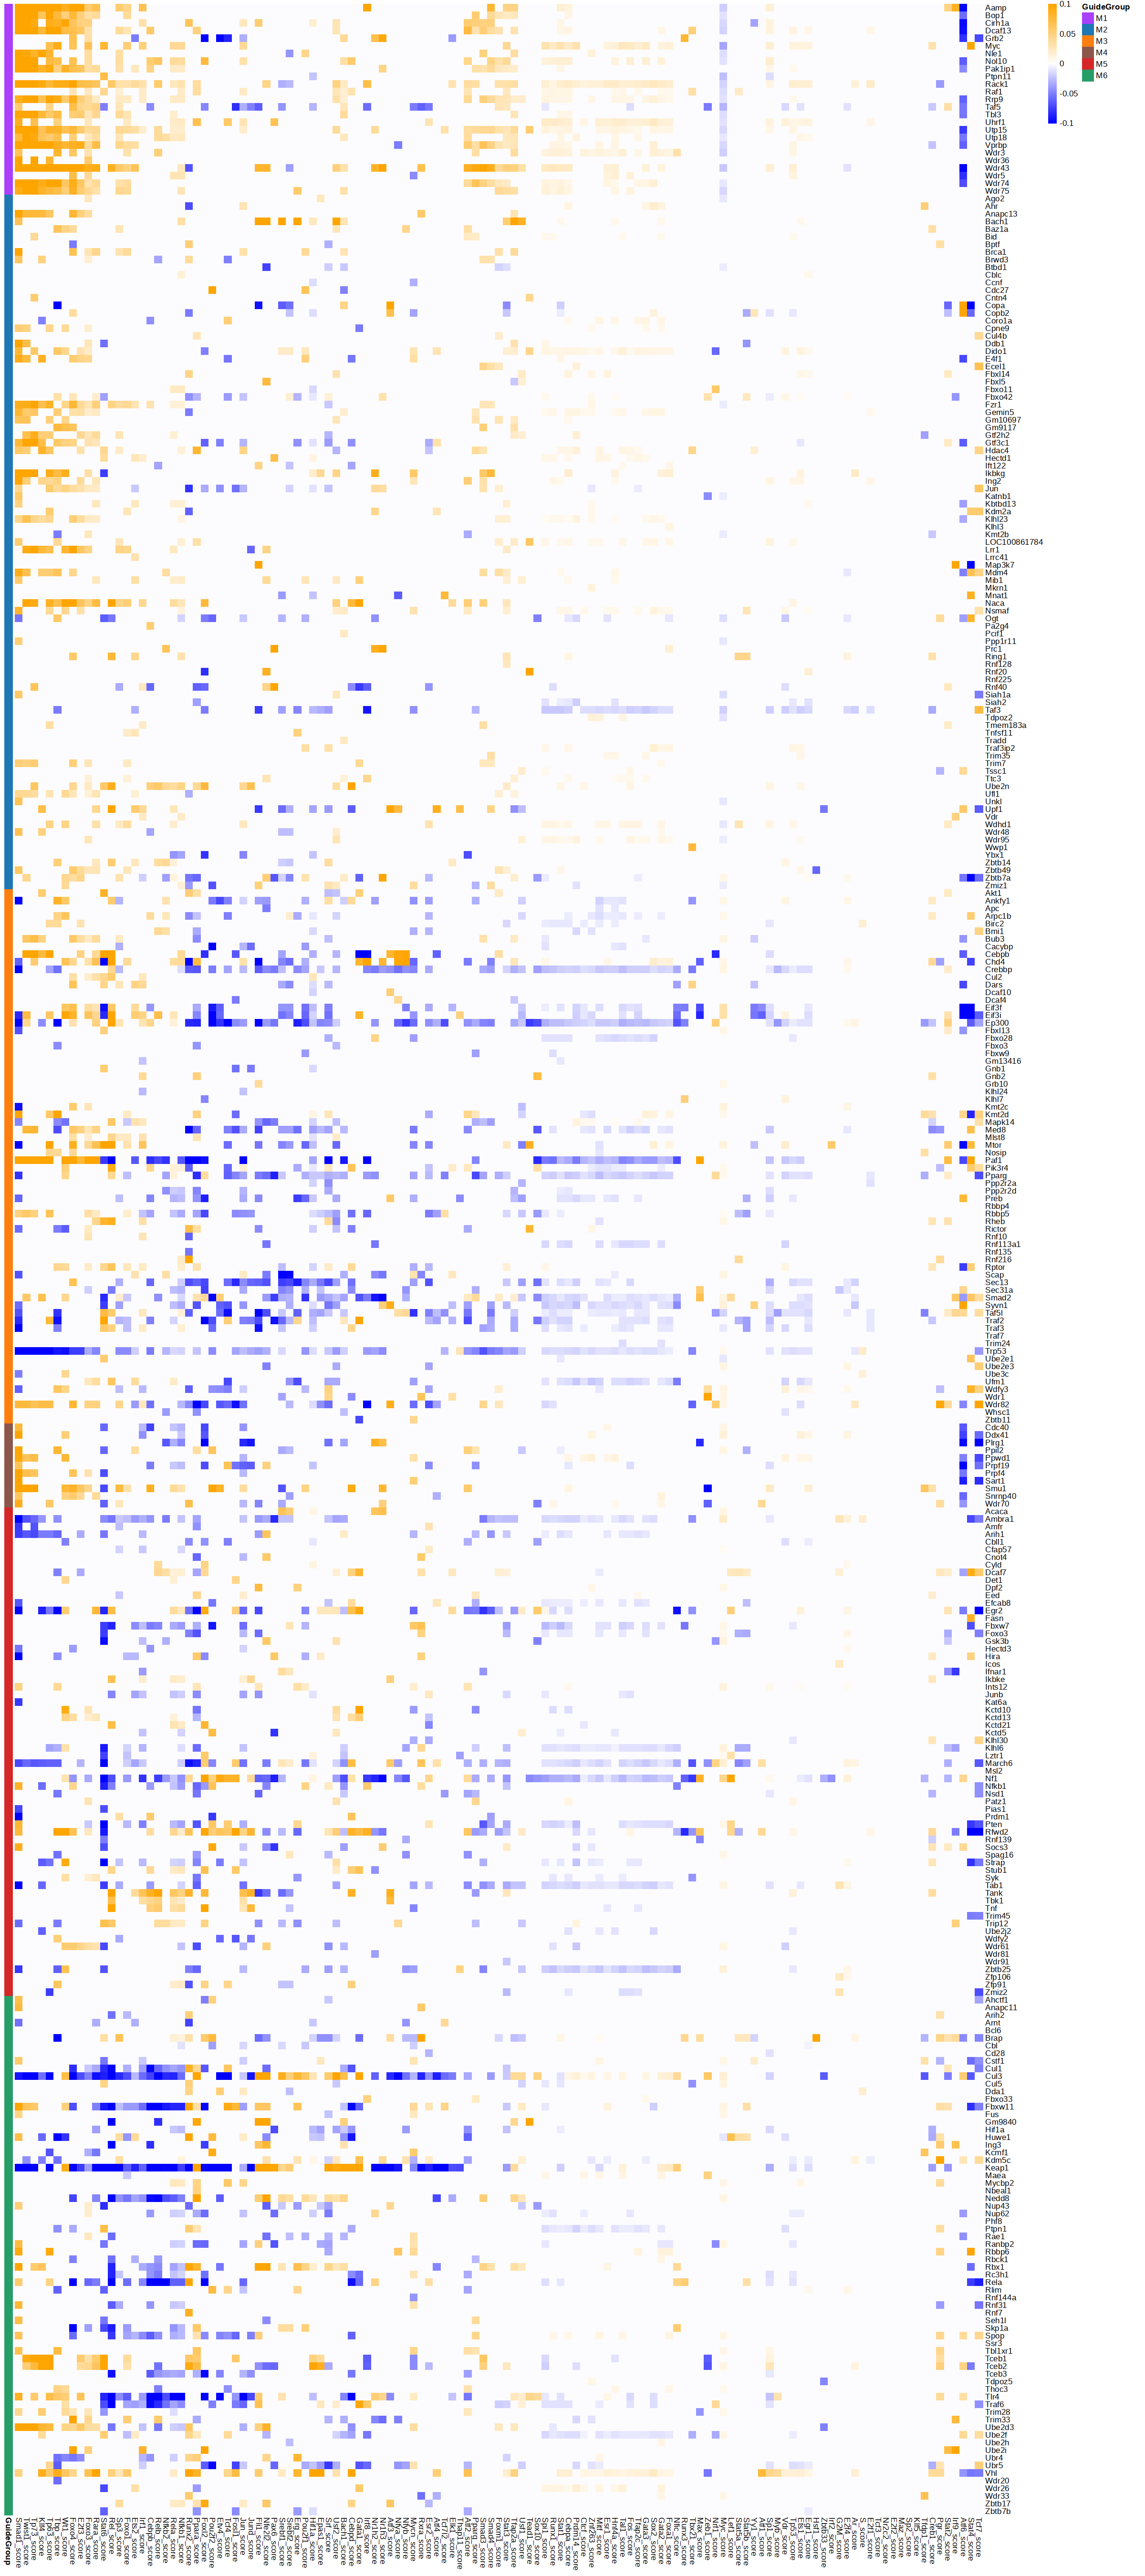

In [5]:
options(repr.plot.width = 20, repr.plot.height = 45)
scoreHeatmap(coefs, annotation = guideModules, clusterRows = FALSE)

## Knockouts and factors with enough signal

Factors affected by too few knockouts, and knockouts affecting too few
factors, carry no structure worth clustering.

In [6]:
informativeTFs <- apply(coefs, 2, function(x) length(which(x != 0)))
coefsTemp <- coefs[, names(informativeTFs[informativeTFs > MIN_KOS_PER_TF])]
informativeKOs <- apply(coefsTemp, 1, function(x) length(which(x != 0)))
coefsTemp <- coefsTemp[informativeKOs > MIN_TFS_PER_KO, ]
dim(coefsTemp)

[1] 156 109

## Order knockouts within their module — Supp. 4J

Each module is clustered on its own, and the resulting order is concatenated,
so modules stay together while knockouts are arranged sensibly inside them.

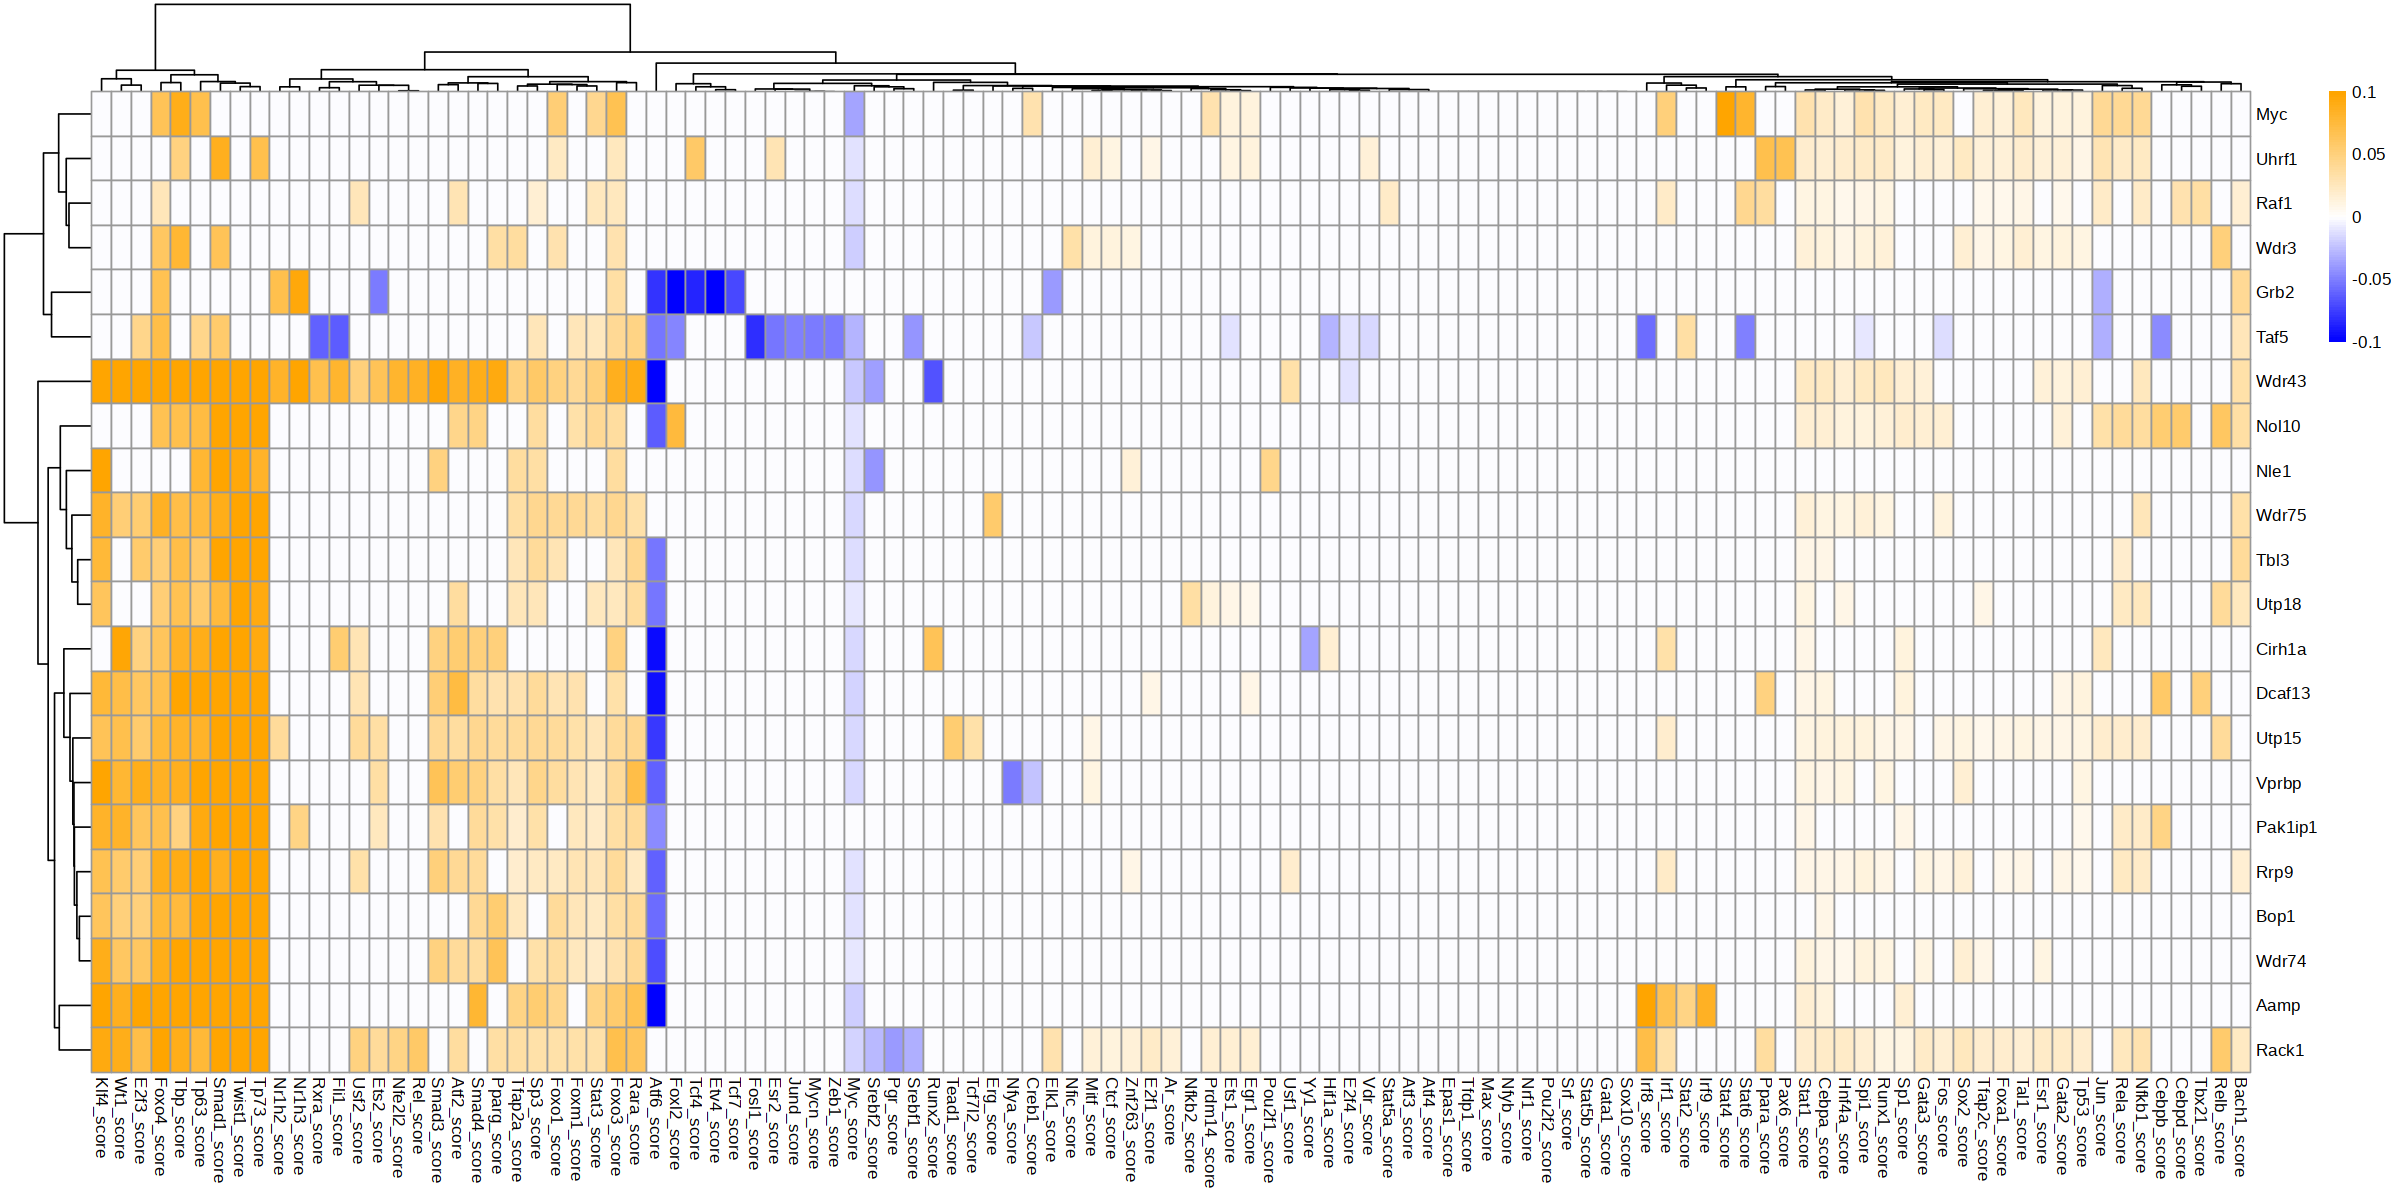

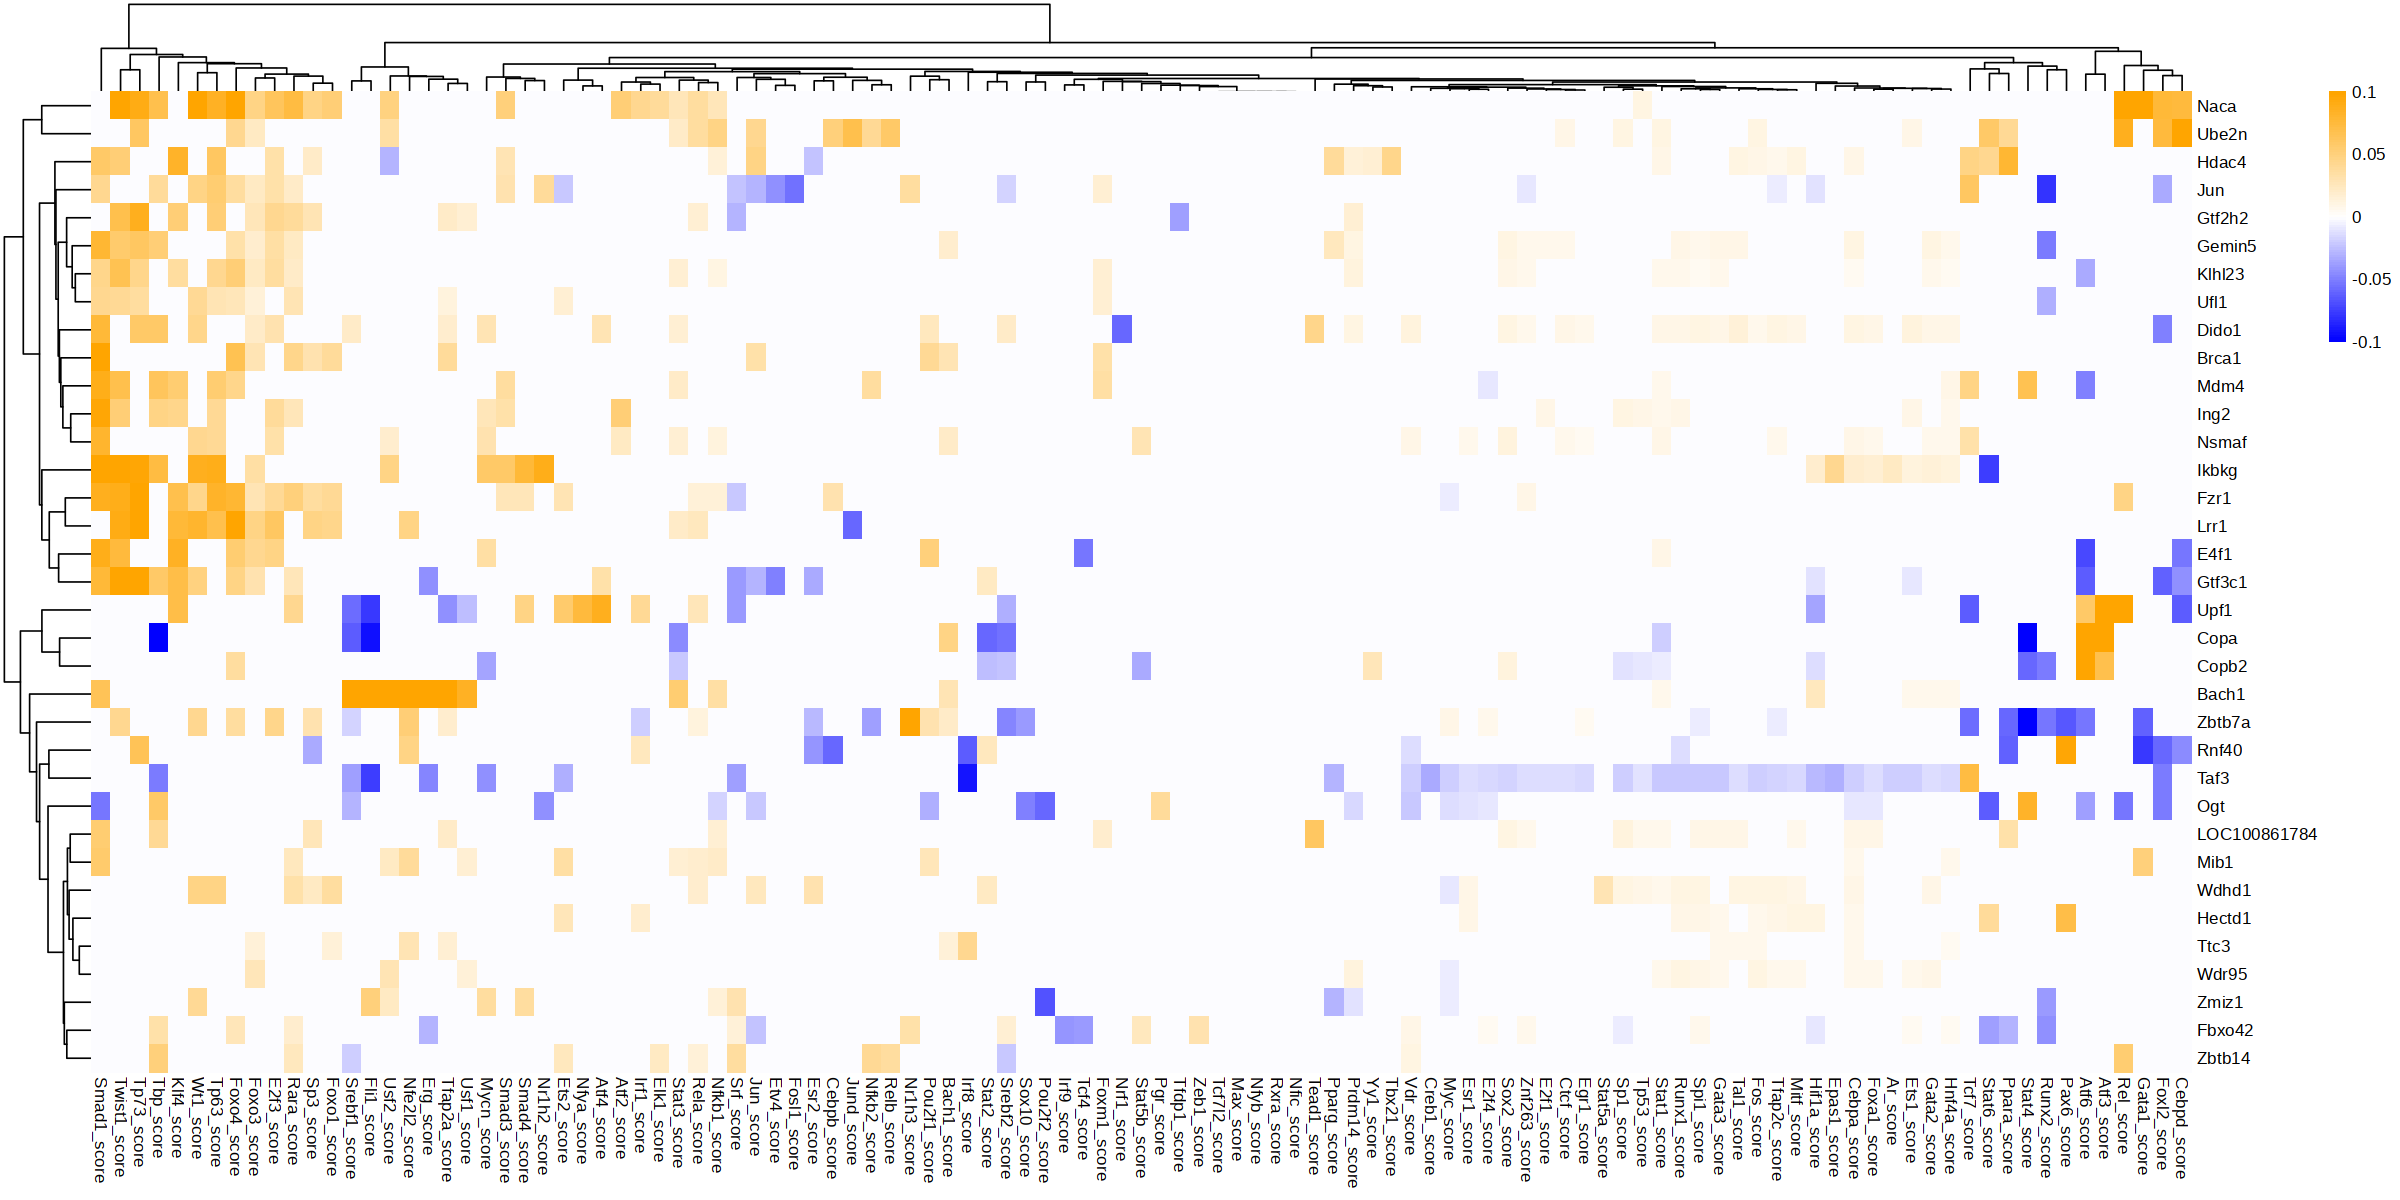

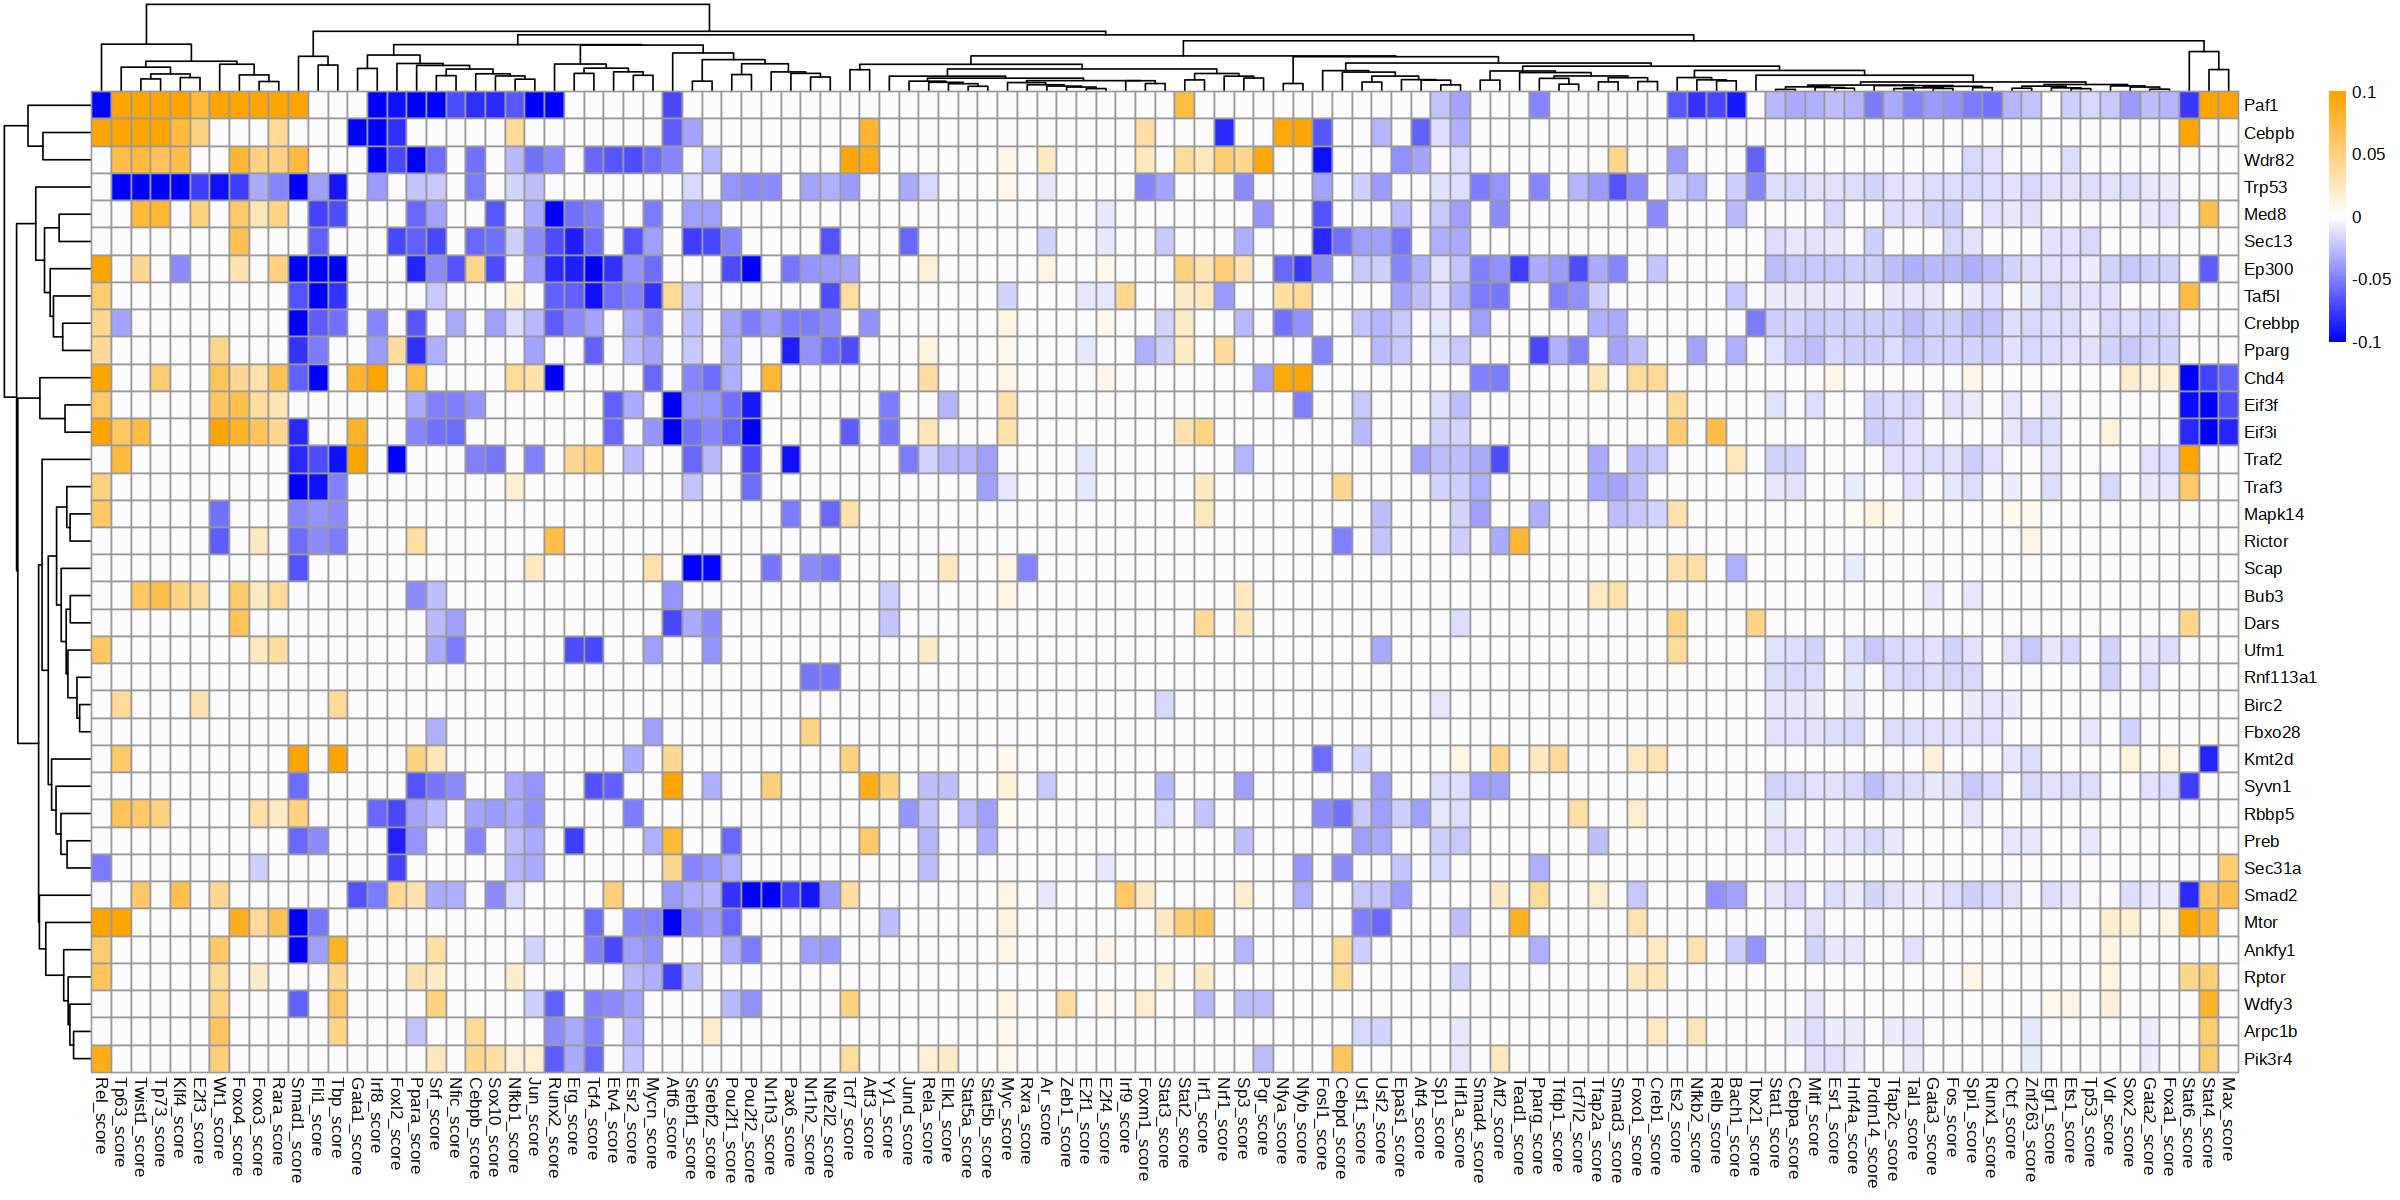

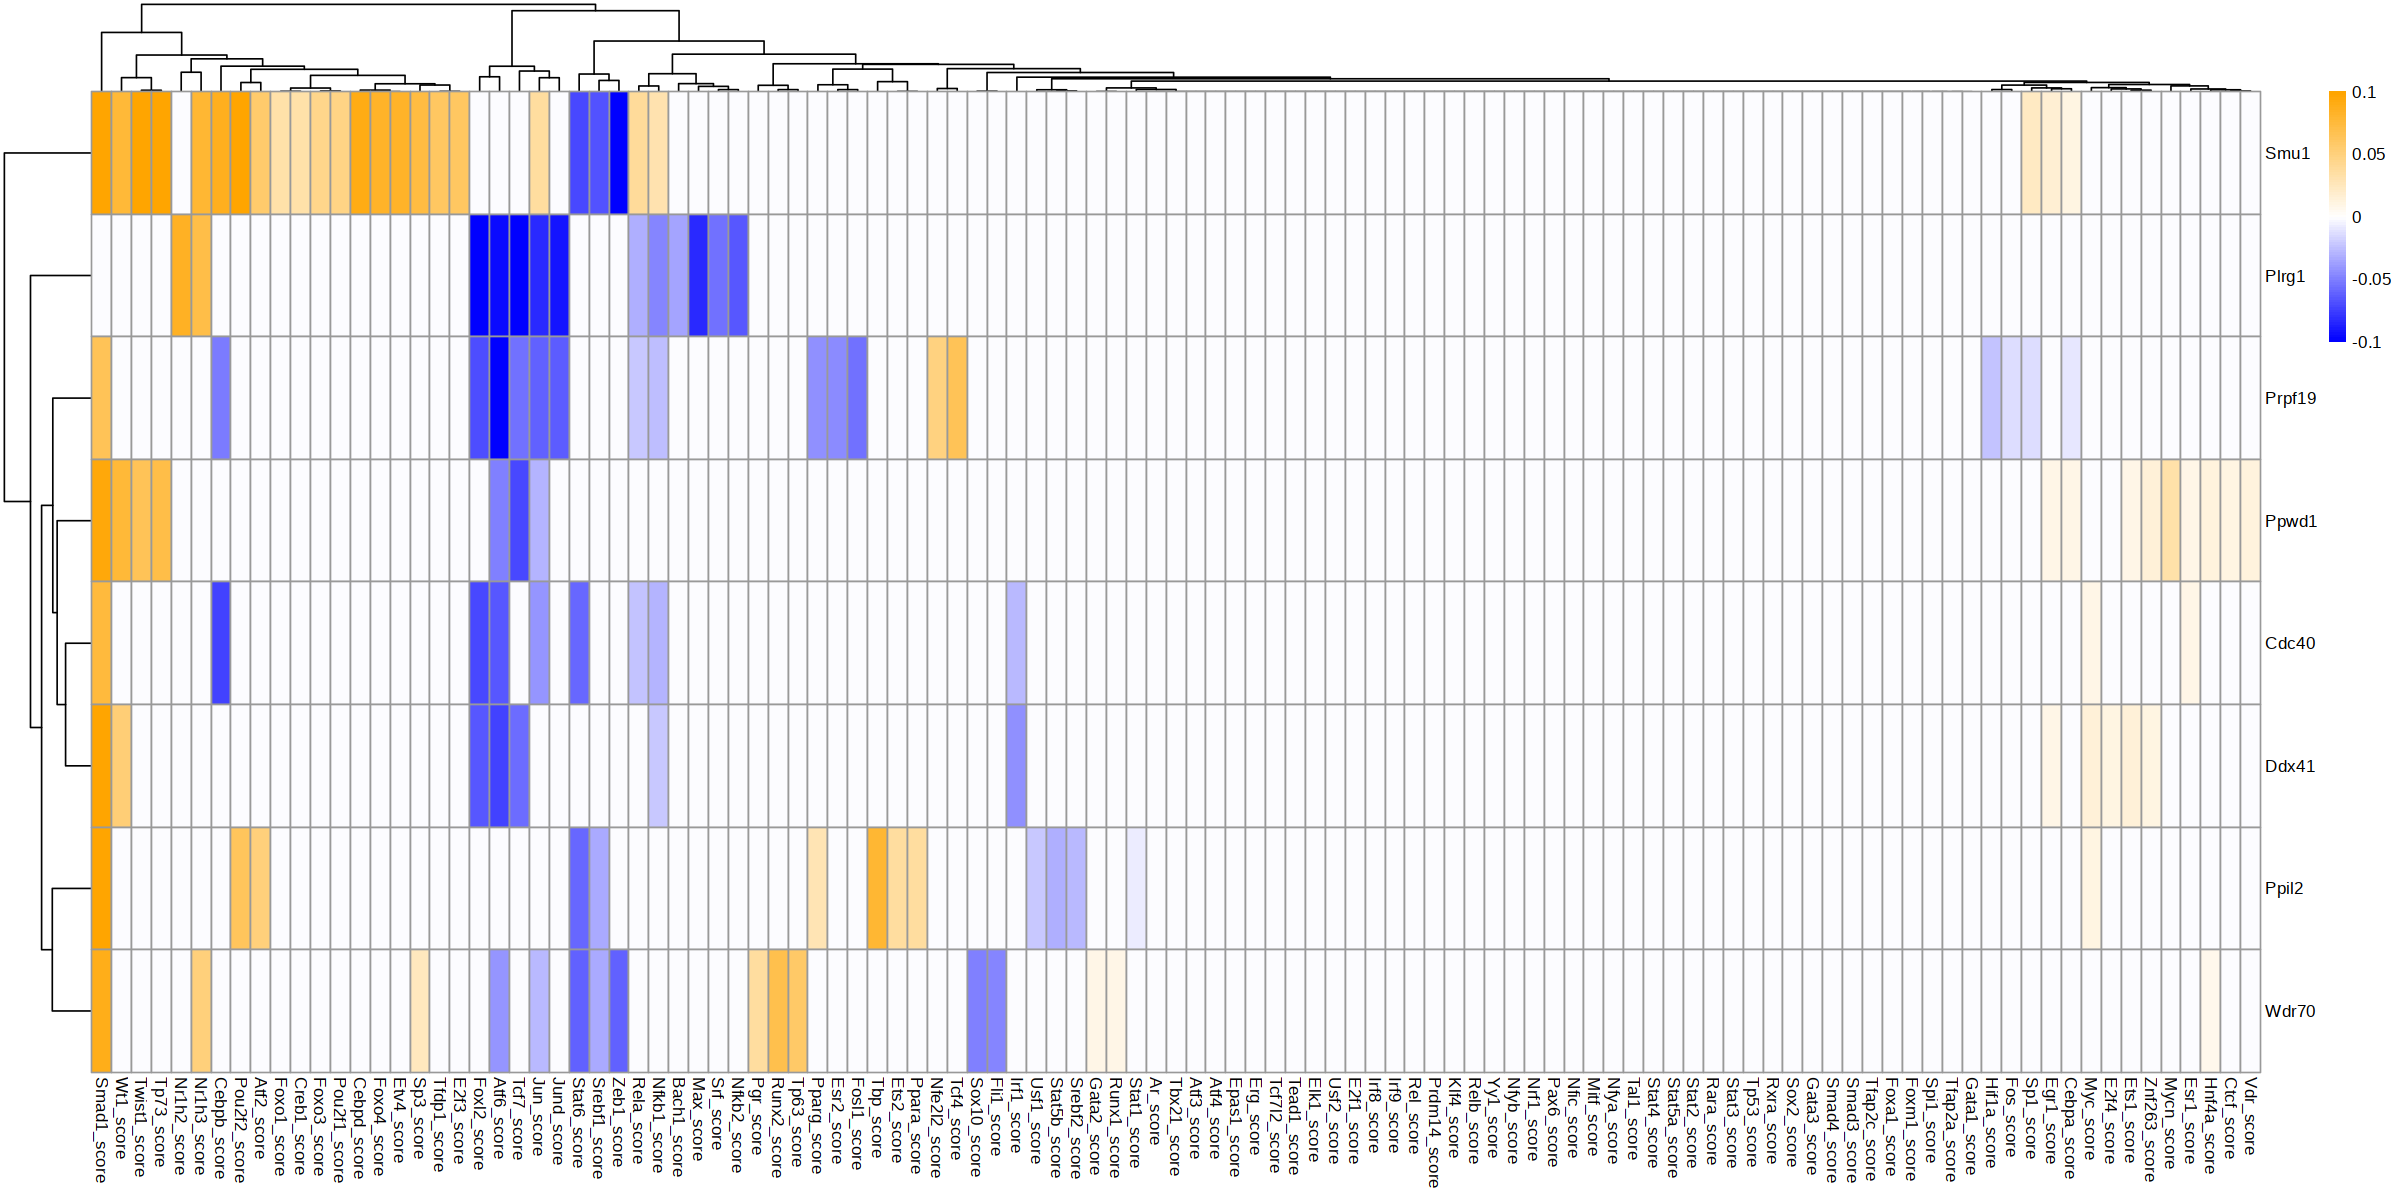

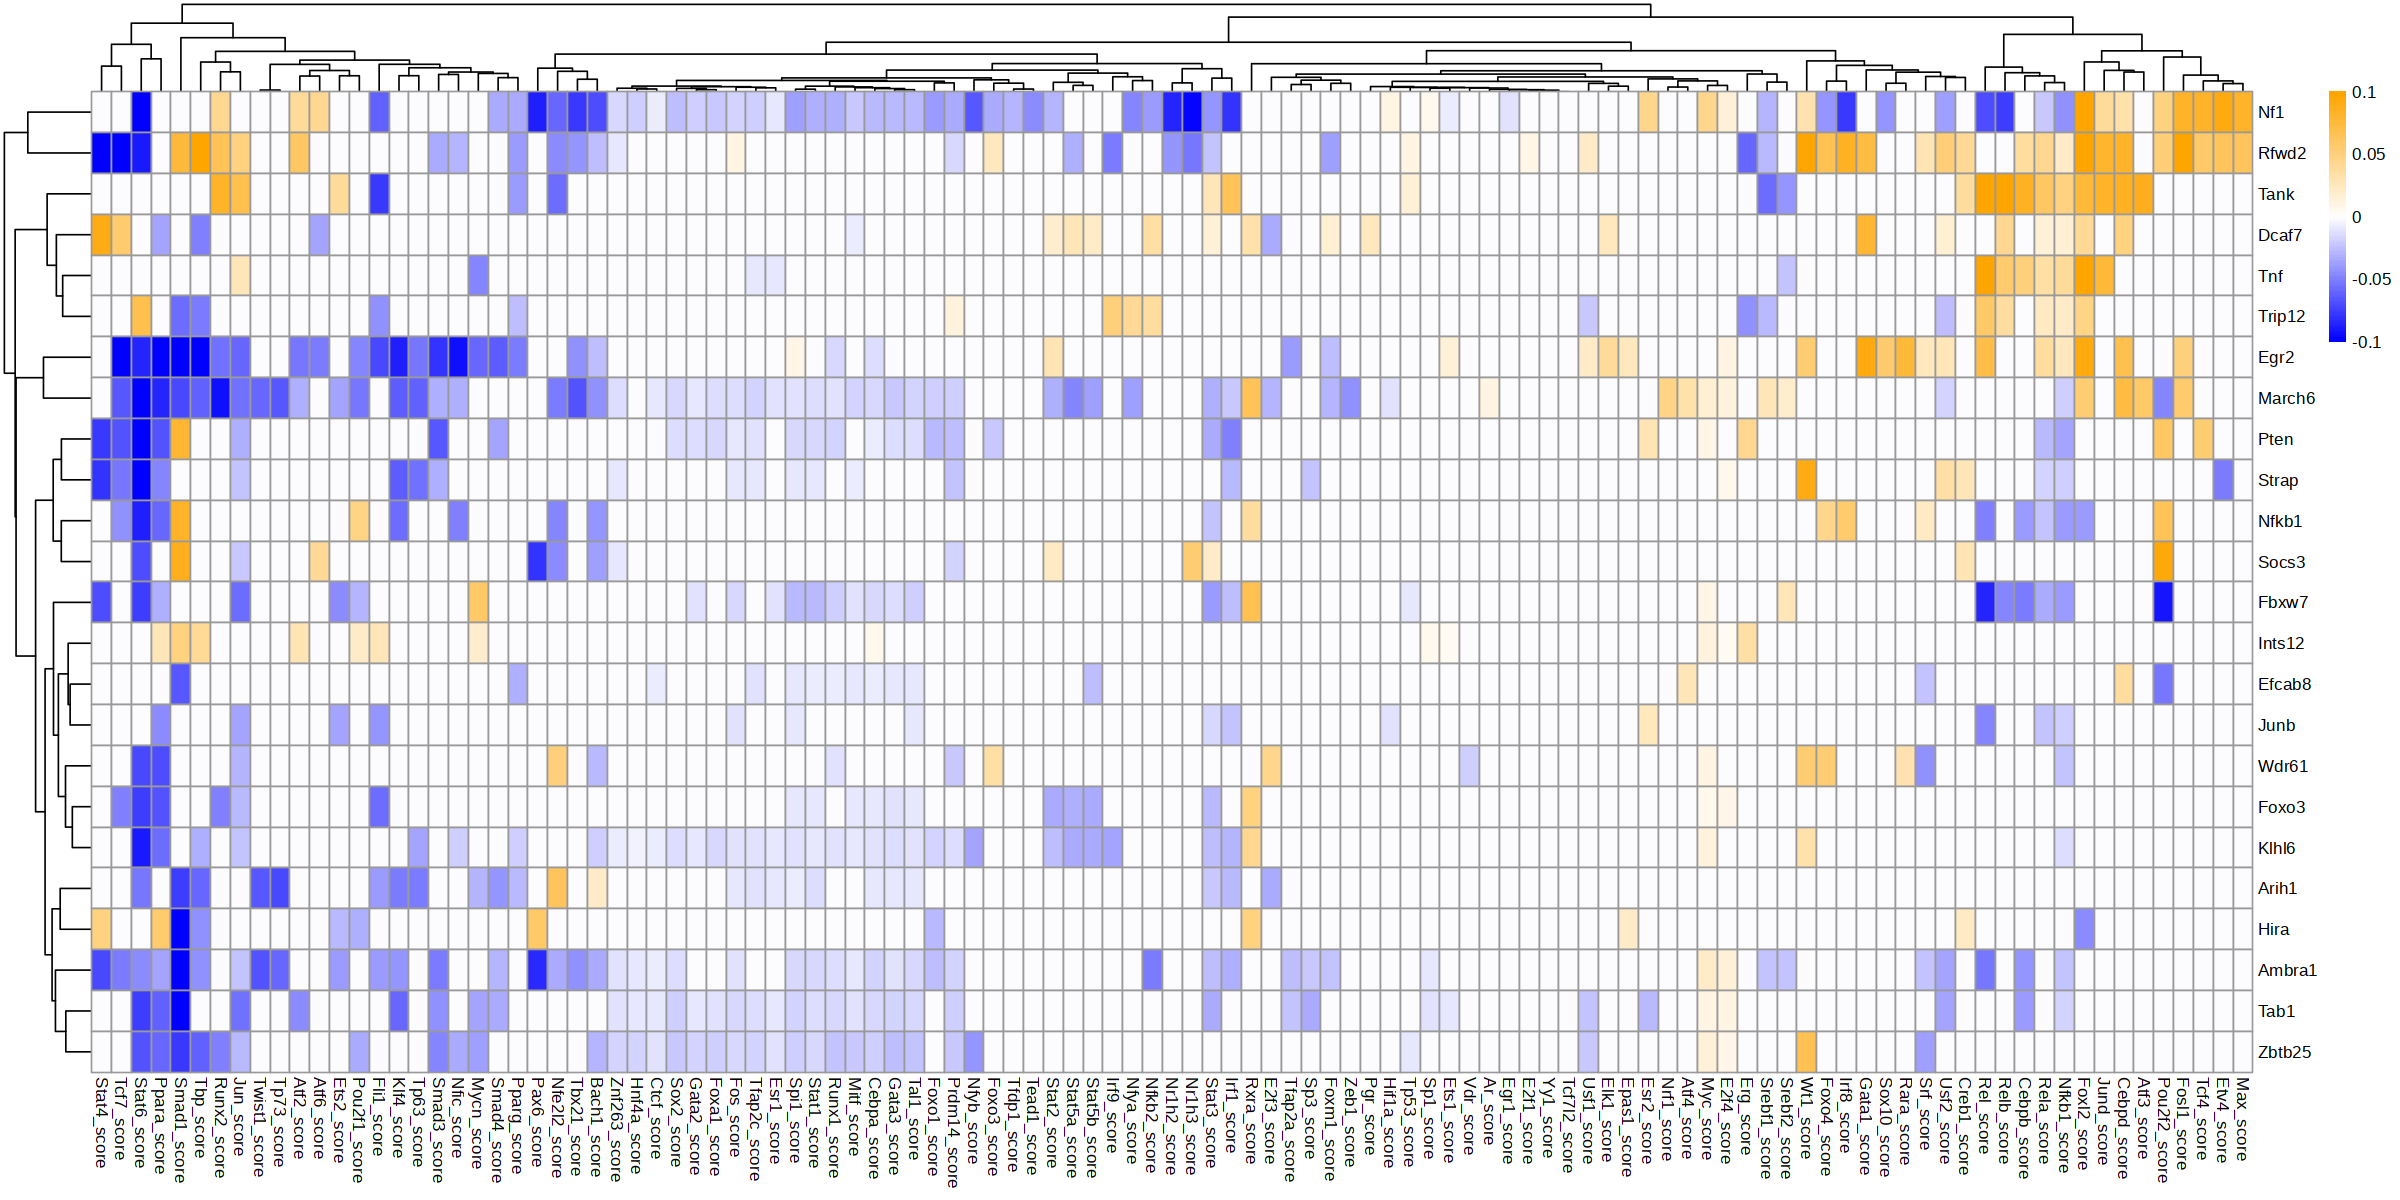

[1] 156

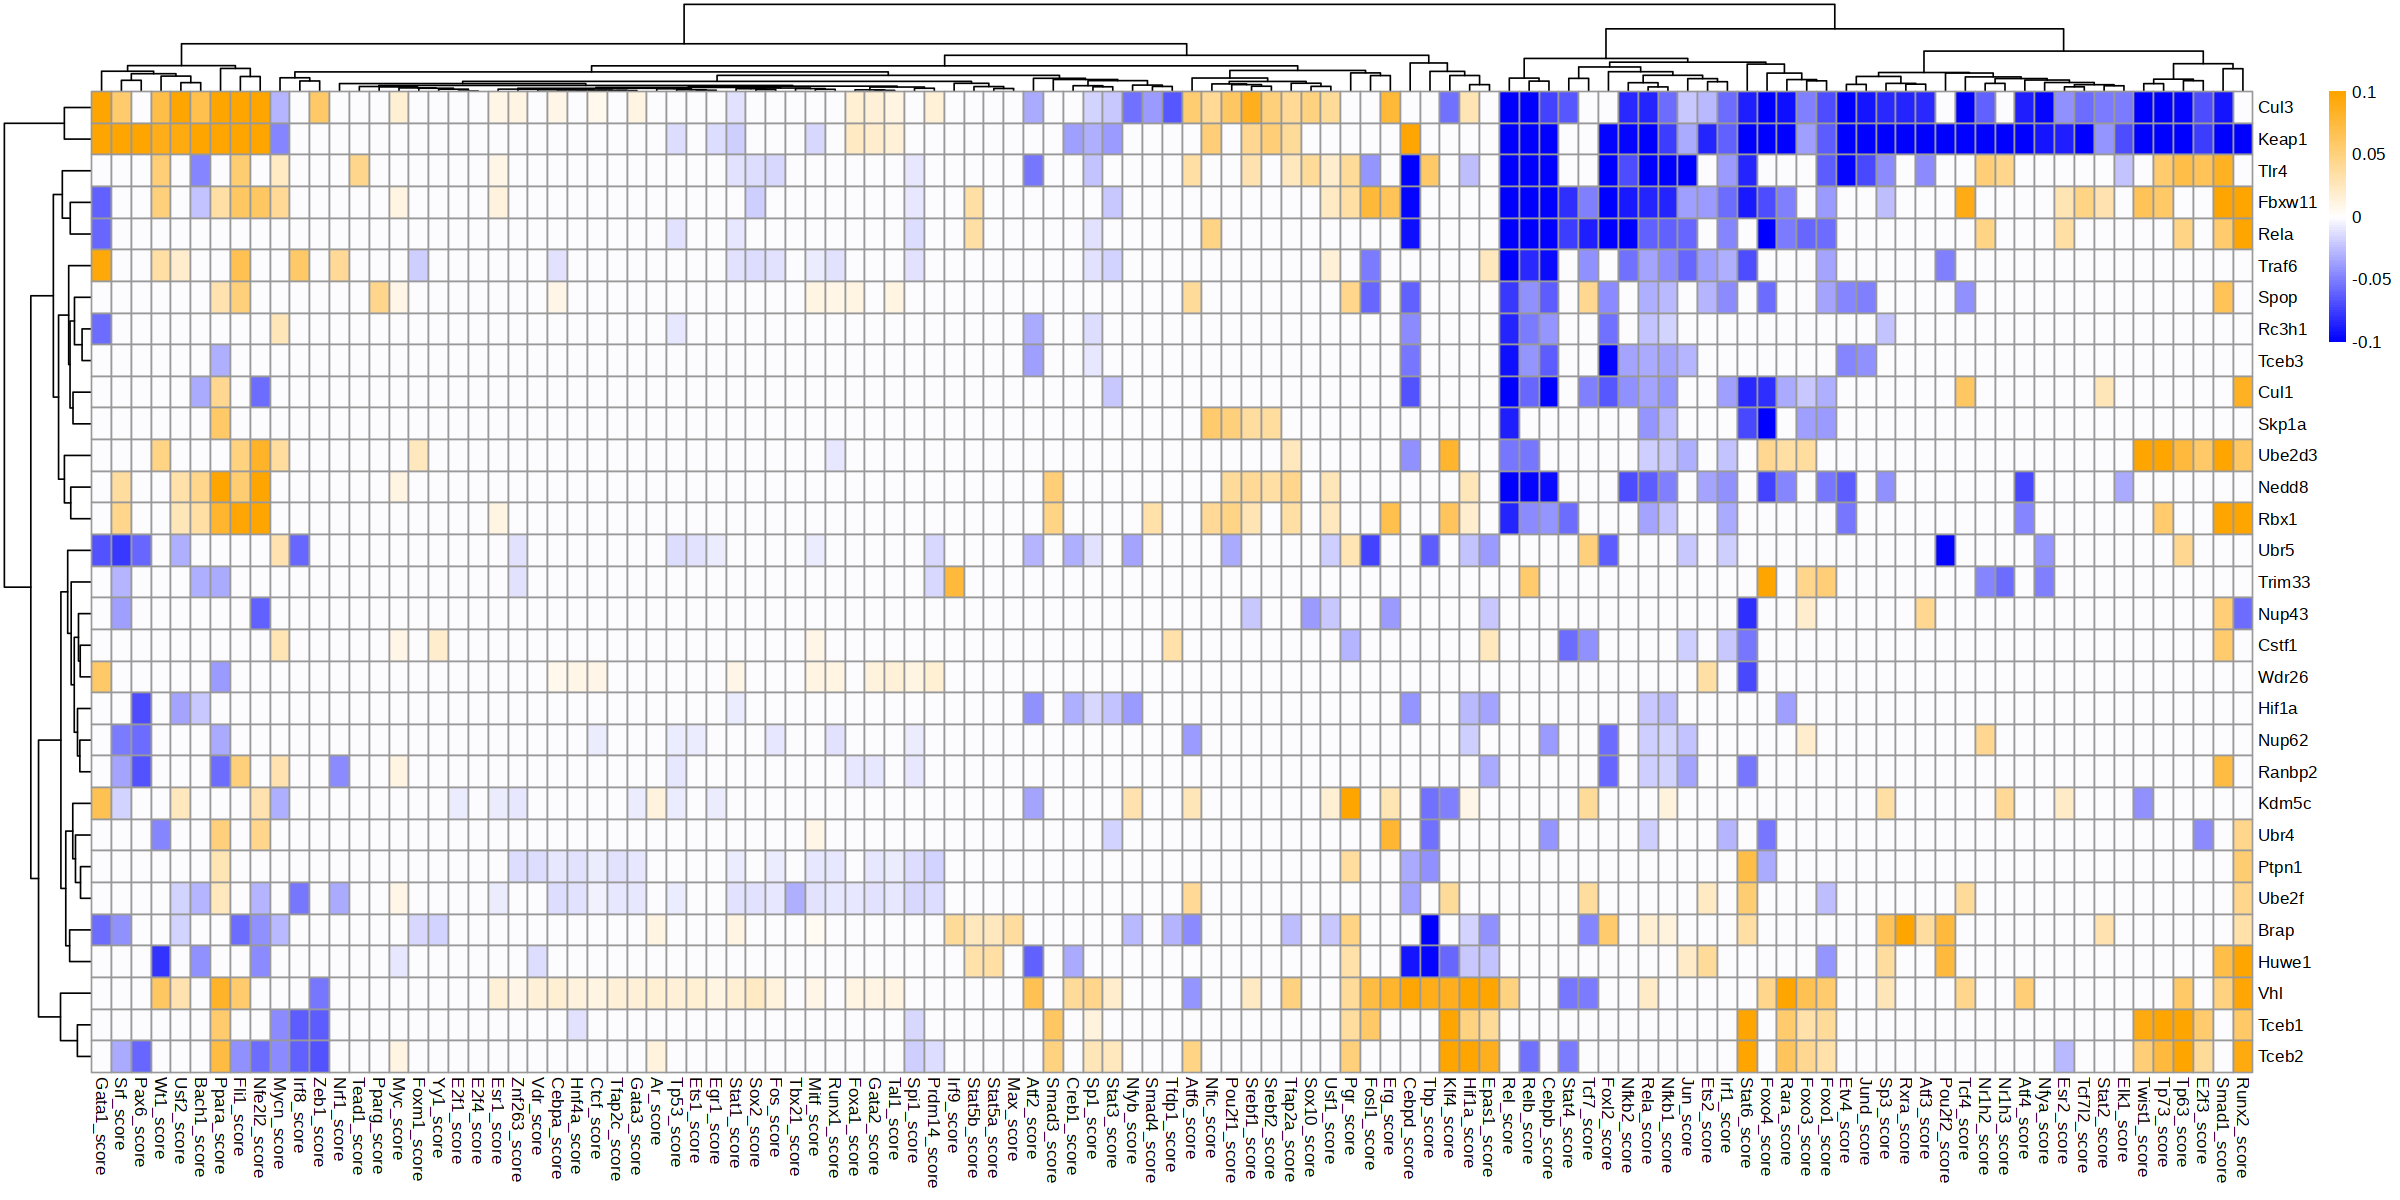

In [7]:
options(repr.plot.width = 20, repr.plot.height = 10)

annoRowTmp <- annoRow[rownames(coefsTemp), ]
allGenesInorder <- c()
for (module in unique(annoRowTmp$GuideGroup)) {
    inModule <- coefsTemp[annoRowTmp[annoRowTmp$GuideGroup == module, "GuideName"], ]
    clustered <- pheatmap(inModule,
                          colorRampPalette(c("blue", "white", "orange"))(100),
                          clustering_method = "ward.D2")
    allGenesInorder <- c(allGenesInorder, rownames(inModule)[clustered$tree_row$order])
}
length(allGenesInorder)

agg_record_1474197023 
                    2

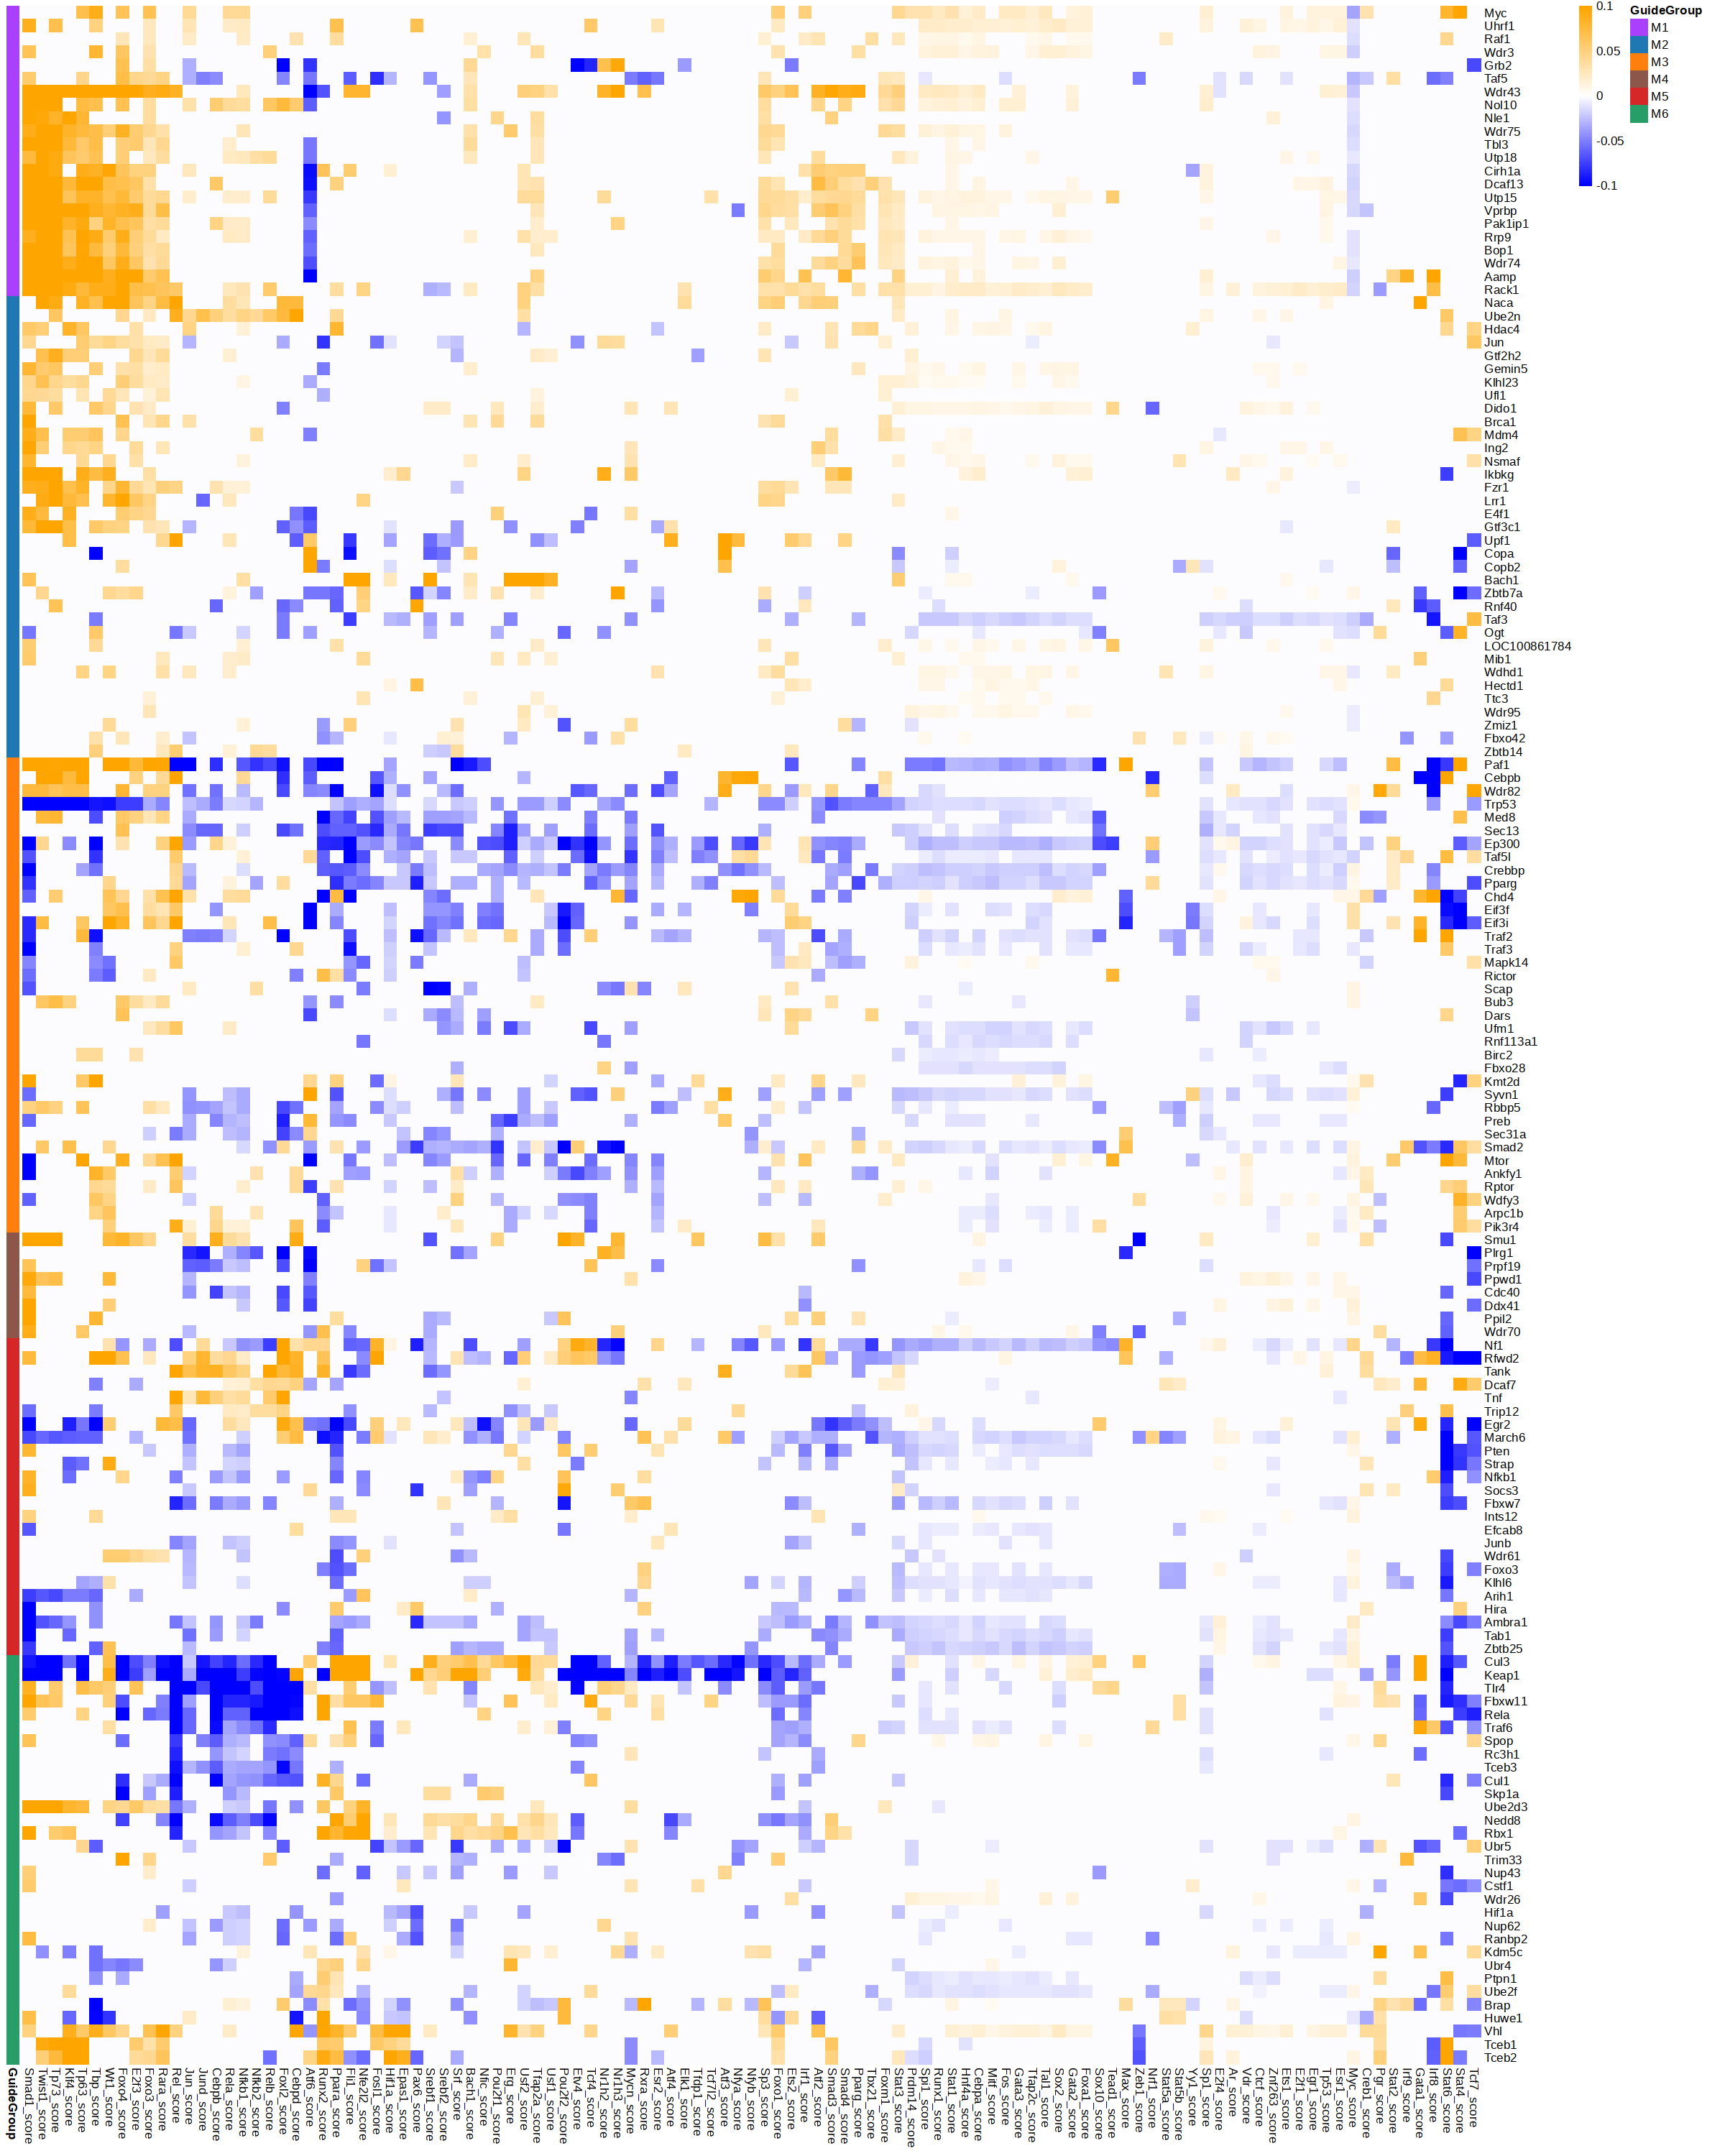

In [8]:
options(repr.plot.width = 20, repr.plot.height = 25)

coefsTemp <- coefsTemp[allGenesInorder, ]
moduleAnnotation <- function(names) {
    a <- annoRow[names, ]
    a$GuideName <- NULL
    a
}
kk <- scoreHeatmap(coefsTemp, annotation = moduleAnnotation(rownames(coefsTemp)), clusterRows = FALSE)
save_pheatmap_pdf(kk, "figures/S_4J.pdf", width = 20, height = 25)

## The E3 ligases alone — Figure 3G

The same view restricted to knockouts that are themselves E3 ligases. The
column order established here is the one written to the matrix.

In [9]:
coefs3 <- coefs[rownames(coefs) %in% e3s, ]
informativeTFs <- apply(coefs3, 2, function(x) length(which(x != 0)))
coefs3 <- coefs3[, names(informativeTFs[informativeTFs > MIN_KOS_PER_TF_E3])]
informativeKOs <- apply(coefs3, 1, function(x) length(which(x != 0)))
coefs3 <- coefs3[informativeKOs > MIN_TFS_PER_KO, ]
dim(coefs3)

[1]  75 106

agg_record_1918993526 
                    2

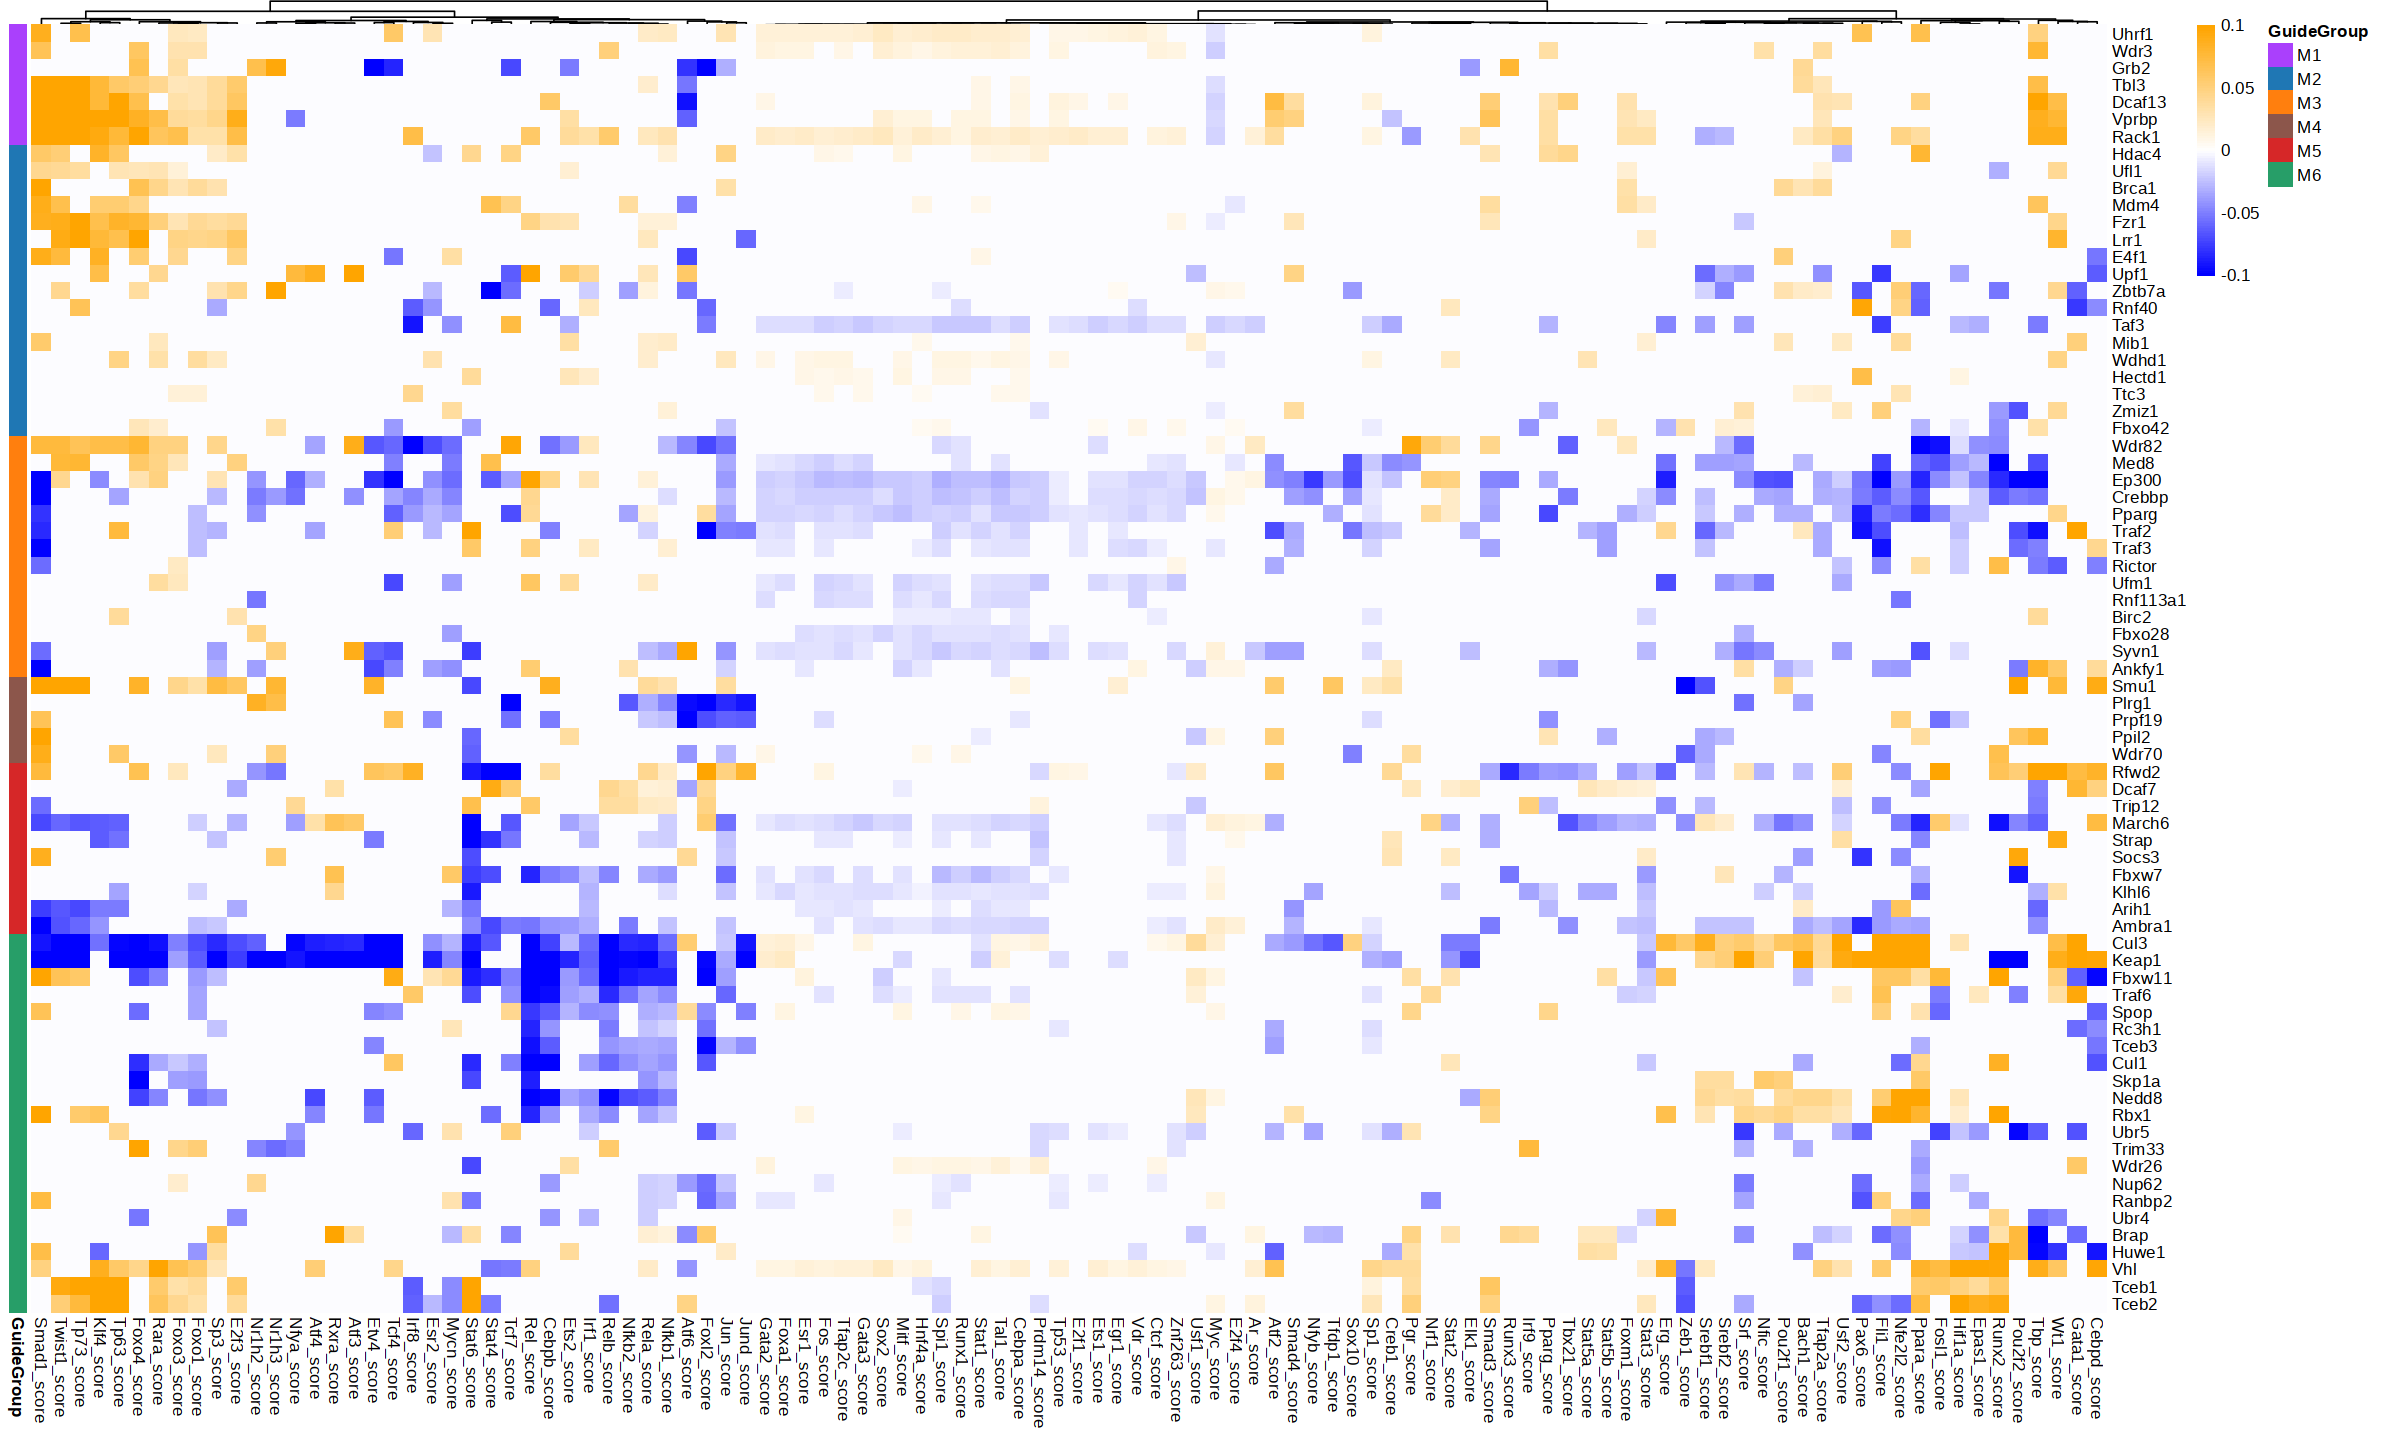

In [10]:
options(repr.plot.width = 20, repr.plot.height = 12)

# order the E3 knockouts by the module ordering established above;
# intersect so knockouts absent here do not come back as empty rows
coefs3 <- coefs3[intersect(allGenesInorder, rownames(coefs3)), ]
xx <- scoreHeatmap(coefs3, annotation = moduleAnnotation(rownames(coefs3)),
                   clusterRows = FALSE, method = "ward.D", treeheightCol = 10)
tforder <- colnames(coefs3)[xx$tree_col$order]
save_pheatmap_pdf(xx, "figures/Figure_3G.pdf", width = 20, height = 12)

write.csv(coefs3[, tforder], "outputs/Figure_3G_matrix.csv")

agg_record_334820064 
                   2

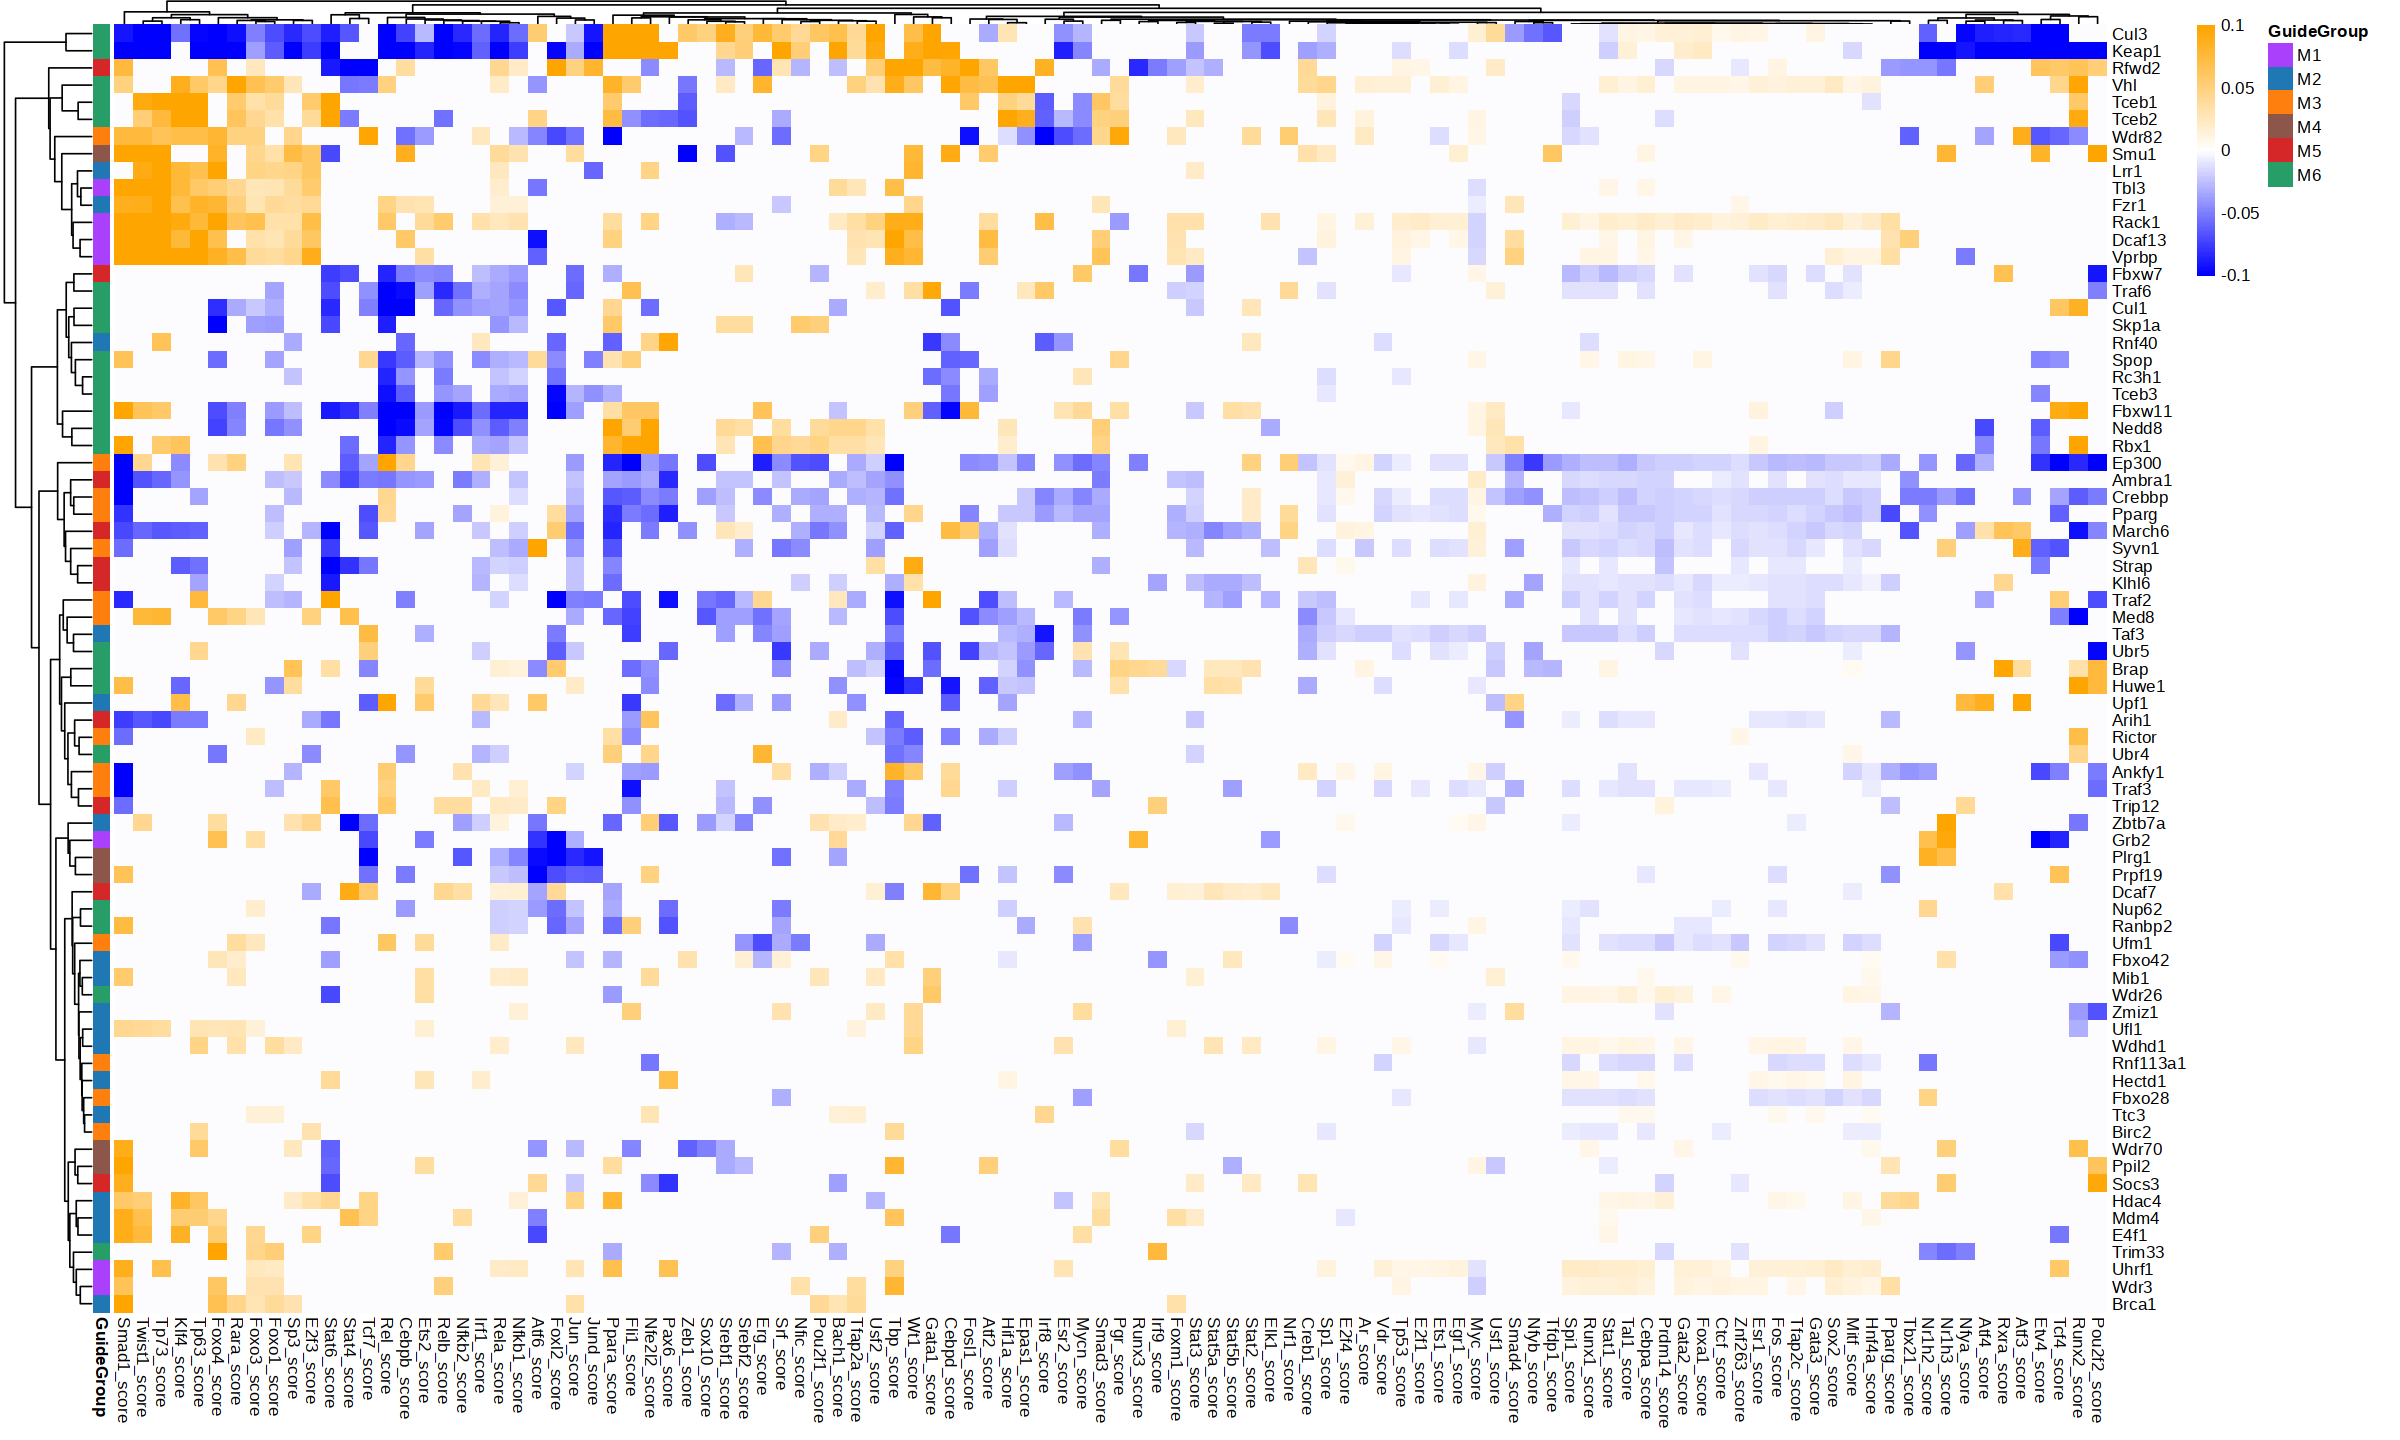

In [11]:
# the same data with the knockouts clustered rather than module-ordered
kk <- scoreHeatmap(coefs3, annotation = moduleAnnotation(rownames(coefs3)), treeheightCol = 10)
save_pheatmap_pdf(kk, "figures/Figure_3G_2.pdf", width = 20, height = 12)

## How distinguishable are the factors?

Transcription factors sharing most of their targets cannot be told apart by
this scoring, so their overlap is worth seeing alongside the panels above.

In [12]:
tfTarget <- read.csv(TF_TARGETS)
scoredTFs <- read.csv(SCORED_TFS)
scoredTFs <- scoredTFs[scoredTFs$X0 %ni% c("S_score", "G2M_score"), ]
scoredTFs <- sapply(scoredTFs, function(x) strsplit(x, "_")[[1]][1])
tfTarget <- tfTarget[tfTarget$source %in% scoredTFs, ]

jaccard <- function(a, b) {
    shared <- length(intersect(a, b))
    shared / (length(a) + length(b) - shared)
}

factors <- unique(tfTarget$source)
overlap <- data.frame(matrix(0, ncol = length(factors), nrow = length(factors)))
colnames(overlap) <- rownames(overlap) <- factors
for (i in factors) {
    for (j in factors) {
        overlap[i, j] <- jaccard(tfTarget[tfTarget$source == i, "target"],
                                 tfTarget[tfTarget$source == j, "target"])
        overlap[j, i] <- overlap[i, j]
    }
}
dim(overlap)

[1] 123 123

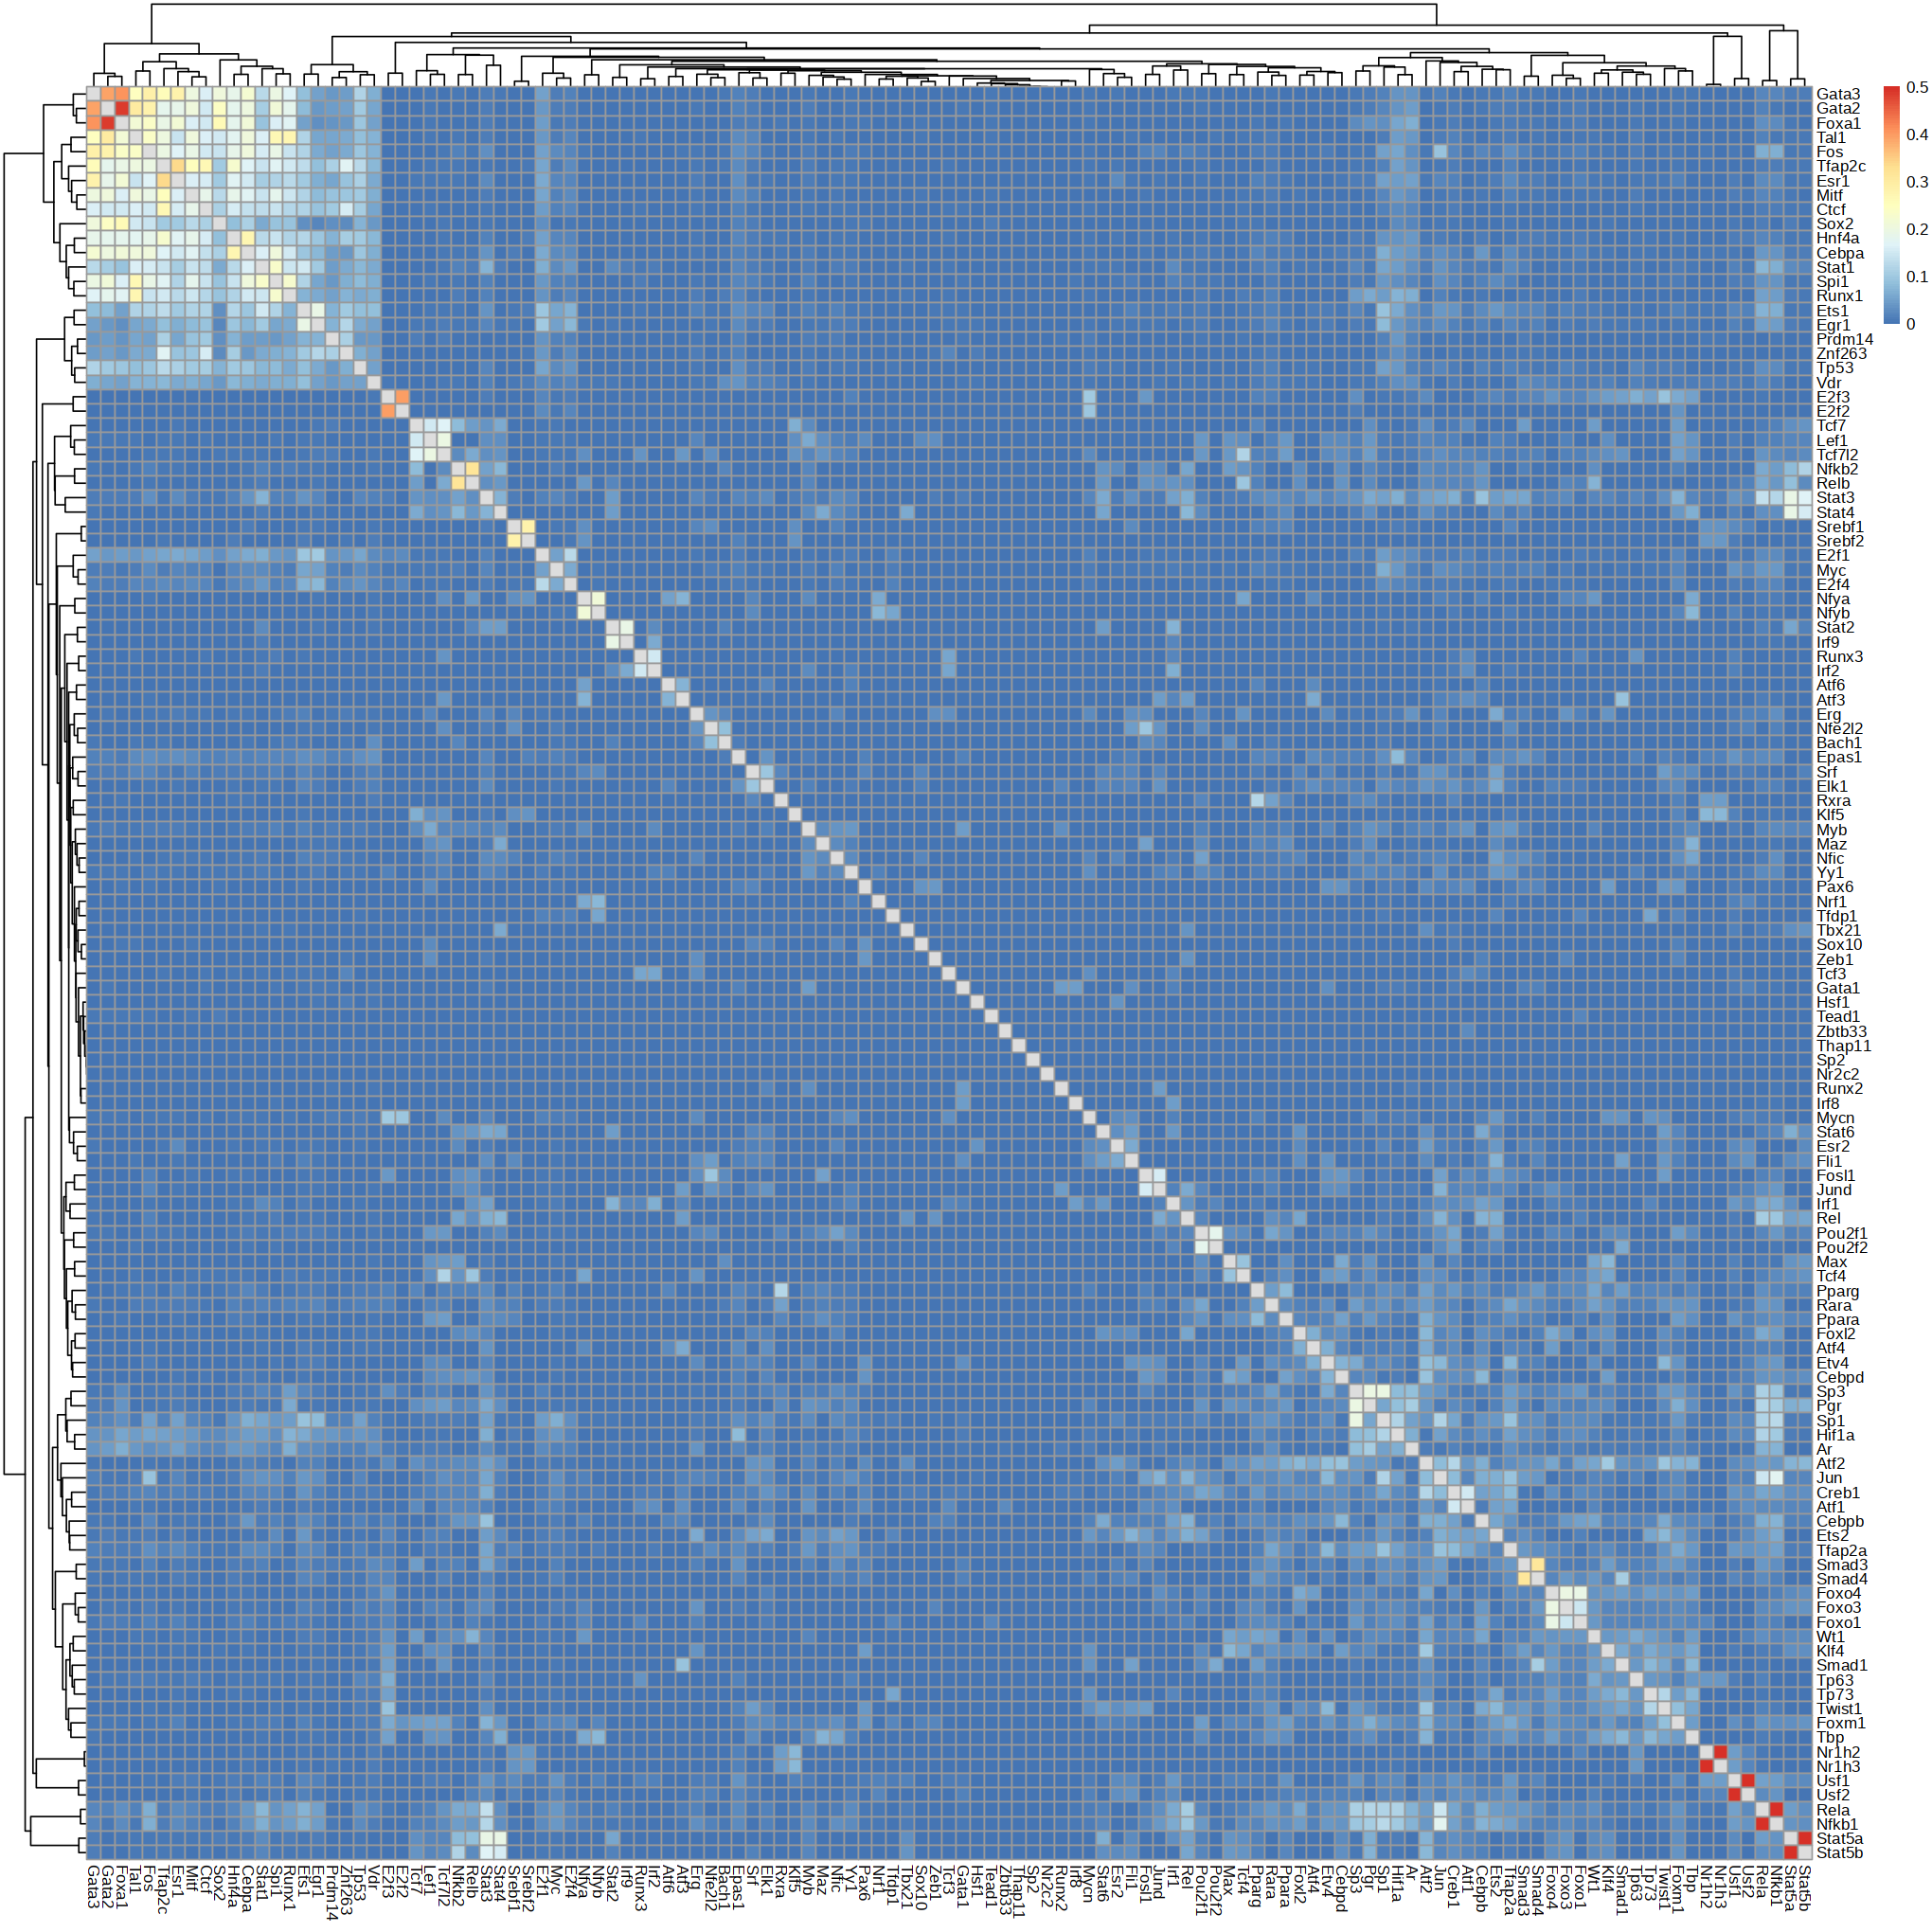

In [13]:
overlap[overlap == 1] <- NA          # the diagonal carries no information
overlap[overlap > JACCARD_CAP] <- JACCARD_CAP

options(repr.plot.width = 17, repr.plot.height = 17)
pheatmap(overlap)